# Resultados

Trabajo de fin de máster

Carlos Sanchiz Pérez

## Dependencias

In [1]:
# Librerías generales
import pandas as pd
import numpy as np

# Pipeline de modelos
from sklearn.pipeline import Pipeline

# Para validación cruzada
from sklearn.model_selection import cross_validate, KFold

# Escaladores
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

# Regresion KKN.
from sklearn.neighbors import KNeighborsRegressor

# Regresion Lineal.
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Regresion SVR.
from sklearn.svm import SVR

# Regresion Arbol de decision.
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Métricas
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error


### Cargamos el conjunto de datos

In [2]:
# Cargamos Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
pisos = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/TFM/Resultados/pisos.csv", sep = ';')
pisos_url = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/TFM/Resultados/pisos_url.csv", sep = ';')

In [ ]:
pisos_url.shape

(38014, 21)

In [ ]:
pisos.shape

(38014, 19)

In [ ]:
pisos_url.duplicated().sum()

np.int64(0)

In [ ]:
pisos.duplicated().sum()

np.int64(1903)

In [ ]:
pisos_regresion = pisos.drop_duplicates()

In [ ]:
pisos_regresion.shape

(36111, 18)

## Modelos Tradicionales

En esta sección comenzamos la parte de regresión, la variable a predecir será el precio de la vivienda, que se encuentra en la columna *precio*. Se introdujo la métrica MAPE, ya que esta mide un error porcentual, y como estamos trabajando con el precio de las viviendas, métricas como MSE o MAE, no nos ofrecen una buena representación, ya que por ejemplo si obtenemos un MAE de 100.000 €, si trabajamos con viviendas de 4.000.000 € es una buena estimación, sin embargo si lo hacemos con viviendas de 200.000 €, no nos está ayudando el modelo.

In [4]:
pisos_regresion = pisos.drop_duplicates()

y_pisos = pisos_regresion['precio']
pisos_regresion = pisos_regresion.drop(columns=['precio'])

#### KNN

El primer tipo de modelo que vamos a ver es el de los vecinos más cercanos, como es un modelo basado en distancias y es posible que empeore el rendimiento si tenemos una dimensión muy alta, por lo que se tomó la decisión de eliminar la columna *localidad*. El resto de variables categóricas las pasamos a dummies.

In [ ]:
# Como las variables tienen que ser numericas o one hot, hacemos lo siguiente:

pisos_regresion_KNN = pisos_regresion.copy()


# Quitamos localidad:

pisos_regresion_KNN = pisos_regresion_KNN.drop(columns=['localidad'])

pisos_regresion_KNN = pd.get_dummies(pisos_regresion_KNN, columns=['tipo'], drop_first=True)
pisos_regresion_KNN = pd.get_dummies(pisos_regresion_KNN, columns=['antiguedad'], drop_first=True)
pisos_regresion_KNN = pd.get_dummies(pisos_regresion_KNN, columns=['conservacion'], drop_first=True)
pisos_regresion_KNN = pd.get_dummies(pisos_regresion_KNN, columns=['terraza'], drop_first=True)
pisos_regresion_KNN = pd.get_dummies(pisos_regresion_KNN, columns=['jardin'], drop_first=True)
pisos_regresion_KNN = pd.get_dummies(pisos_regresion_KNN, columns=['orientacion'], drop_first=True)
pisos_regresion_KNN = pd.get_dummies(pisos_regresion_KNN, columns=['garaje'], drop_first=True)
pisos_regresion_KNN = pd.get_dummies(pisos_regresion_KNN, columns=['piscina'], drop_first=True)
pisos_regresion_KNN = pd.get_dummies(pisos_regresion_KNN, columns=['aire_acondicionado'], drop_first=True)
pisos_regresion_KNN = pd.get_dummies(pisos_regresion_KNN, columns=['trastero'], drop_first=True)
pisos_regresion_KNN = pd.get_dummies(pisos_regresion_KNN, columns=['ascensor'], drop_first=True)
pisos_regresion_KNN = pd.get_dummies(pisos_regresion_KNN, columns=['planta'], drop_first=True)

Con el objetivo de seleccionar el mejor modelo posible, se probó con los siguientes k: 1, 3, 5, 7, 10, 15 y 20. Además, también probamos con un escalado *MinMax* y un *Robust*, además de probar el modelo sin ningún escalador, para comparar resultados. Otro aspecto a tener en cuenta fue la decisión de implementar ```weights='distance'```, de esta manera se da más peso a los vecinos cercanos y dado que estamos en una dimensión relativamente alta, así evitamos la influencia de vecinos que están lejos aunque sean de los más próximos. Para la evaluación, usamos validación cruzada, con 5 particiones, y las métricas utilizadas son $R^2$, MSE y MAPE, siendo está última la más importante.

In [ ]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
from sklearn.neighbors import KNeighborsRegressor

# KFold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Métricas
metricas = {
    'r2': 'r2',
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'mape': 'neg_mean_absolute_percentage_error'
}

# Valores de k a probar
k_values = [1, 3, 5, 7, 10, 15, 20]

def evaluar_modelo(nombre, pipeline_base):
    print(f"===== {nombre} =====")

    mejor_mape = float('inf')
    mejor_k = None
    mejores_metricas = None

    for k in k_values:
        pipeline = pipeline_base(k)

        scores = cross_validate(
            pipeline,
            pisos_regresion_KNN,
            y_pisos,
            cv=kfold,
            scoring=metricas,
            return_train_score=True
        )

        r2 = scores['test_r2'].mean()
        mse = -scores['test_mse'].mean()
        mae = -scores['test_mae'].mean()
        mape = -scores['test_mape'].mean()

        print(f"k = {k} -> R^2: {r2:.4f} | MSE: {mse:.4e} | MAE: {mae:.4f} | MAPE: {mape:.4f}")

        if mape < mejor_mape:
            mejor_mape = mape
            mejor_k = k
            mejores_metricas = scores

    print("\nMejor k:", mejor_k)
    print("R2 medio:", mejores_metricas['test_r2'].mean())
    print("MSE medio:", -mejores_metricas['test_mse'].mean())
    print("MAE medio:", -mejores_metricas['test_mae'].mean())
    print("MAPE medio:", -mejores_metricas['test_mape'].mean())
    print("\n")


# KNN + MinMax
evaluar_modelo(
    "KNN + MinMaxScaler",
    lambda k: Pipeline([
        ('scaler', MinMaxScaler()),
        ('model', KNeighborsRegressor(n_neighbors=k, weights='distance'))
    ])
)

# KNN + Robust
evaluar_modelo(
    "KNN + RobustScaler",
    lambda k: Pipeline([
        ('scaler', RobustScaler()),
        ('model', KNeighborsRegressor(n_neighbors=k, weights='distance'))
    ])
)

# KNN + StandardScaler (NUEVO)
evaluar_modelo(
    "KNN + StandardScaler",
    lambda k: Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsRegressor(n_neighbors=k, weights='distance'))
    ])
)

# KNN sin escalado
evaluar_modelo(
    "KNN sin escalador",
    lambda k: KNeighborsRegressor(n_neighbors=k, weights='distance')
)

===== KNN + MinMaxScaler =====
k = 1 -> R^2: 0.3729 | MSE: 1.3692e+11 | MAE: 184285.4655 | MAPE: 0.4384
k = 3 -> R^2: 0.5440 | MSE: 9.9637e+10 | MAE: 164014.5317 | MAPE: 0.3998
k = 5 -> R^2: 0.5784 | MSE: 9.2109e+10 | MAE: 159579.7200 | MAPE: 0.3927
k = 7 -> R^2: 0.5919 | MSE: 8.9173e+10 | MAE: 157599.8625 | MAPE: 0.3904
k = 10 -> R^2: 0.6014 | MSE: 8.7111e+10 | MAE: 156558.9198 | MAPE: 0.3907
k = 15 -> R^2: 0.6045 | MSE: 8.6449e+10 | MAE: 156449.7775 | MAPE: 0.3925
k = 20 -> R^2: 0.6031 | MSE: 8.6772e+10 | MAE: 157058.4048 | MAPE: 0.3966

Mejor k: 7
R2 medio: 0.5918650483369439
MSE medio: 89172644816.41473
MAE medio: 157599.8624541584
MAPE medio: 0.3903875445771104


===== KNN + RobustScaler =====
k = 1 -> R^2: 0.4977 | MSE: 1.0967e+11 | MAE: 163058.0213 | MAPE: 0.3683
k = 3 -> R^2: 0.6498 | MSE: 7.6482e+10 | MAE: 142710.0733 | MAPE: 0.3311
k = 5 -> R^2: 0.6781 | MSE: 7.0317e+10 | MAE: 138204.5890 | MAPE: 0.3237
k = 7 -> R^2: 0.6897 | MSE: 6.7789e+10 | MAE: 136966.8319 | MAPE: 0.3234


Se observa que el modelo óptimo es KNN con k = 7 y con el escalador Robust, obteniedo un MAPE de 0.3, lo que nos indica de que el modelo si es capaz de captar ciertas tendencias.

Vemos como los peores modelos son los que no se ha realizado un escalado, después con el escalador *MinMax* se obtiene una ligera mejoría, y con el *Robust* obtenemos hasta un 0.06 de mejora, como se comentó en la parte de clasificación, vemos como el hecho de que el mejor escalador sea *Robust*, es posiblemente a la presencia de *Outliers* que afectan tanto a un problema de clasificación como a un problema de regresión.

#### Regresión Lineal

El segundo tipo de modelo a estudiar es el de regresión lineal. La única columna que eliminaremos es *localidad*.

In [ ]:
# Como las variables tienen que ser numericas o one hot, hacemos lo siguiente:

pisos_regresion_Lineal = pisos_regresion.copy()


# Quitamos localidad:

pisos_regresion_Lineal = pisos_regresion_Lineal.drop(columns=['localidad'])

pisos_regresion_Lineal = pd.get_dummies(pisos_regresion_Lineal, columns=['tipo'], drop_first=True)
pisos_regresion_Lineal = pd.get_dummies(pisos_regresion_Lineal, columns=['antiguedad'], drop_first=True)
pisos_regresion_Lineal = pd.get_dummies(pisos_regresion_Lineal, columns=['conservacion'], drop_first=True)
pisos_regresion_Lineal = pd.get_dummies(pisos_regresion_Lineal, columns=['terraza'], drop_first=True)
pisos_regresion_Lineal = pd.get_dummies(pisos_regresion_Lineal, columns=['jardin'], drop_first=True)
pisos_regresion_Lineal = pd.get_dummies(pisos_regresion_Lineal, columns=['orientacion'], drop_first=True)
pisos_regresion_Lineal = pd.get_dummies(pisos_regresion_Lineal, columns=['garaje'], drop_first=True)
pisos_regresion_Lineal = pd.get_dummies(pisos_regresion_Lineal, columns=['piscina'], drop_first=True)
pisos_regresion_Lineal = pd.get_dummies(pisos_regresion_Lineal, columns=['aire_acondicionado'], drop_first=True)
pisos_regresion_Lineal = pd.get_dummies(pisos_regresion_Lineal, columns=['trastero'], drop_first=True)
pisos_regresion_Lineal = pd.get_dummies(pisos_regresion_Lineal, columns=['ascensor'], drop_first=True)
pisos_regresion_Lineal = pd.get_dummies(pisos_regresion_Lineal, columns=['planta'], drop_first=True)

Probaremos con los escaladores MinMax y Robust, además de modelar sin escalar, para ver la diferencia. También, probaremos con las penalizaciones Ridge y Lasso, y compararemos con el modelo básico para ver si mejora el rendimiento del modelo. Para la evaluación utilizaremos validación cruzada, con una partición en 5 splitsy las métricas serán $R^2$, MSE y MAPE.

In [ ]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np

# Escaladores
scalers = {
    'Sin Escalar': None,
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
    'StandardScaler': StandardScaler()
}

# Modelos
modelos = {
    'LR_Base': LinearRegression(),
    'LR_Ridge': Ridge(alpha=1.0),
    'LR_Lasso': Lasso(alpha=0.1)
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
resultados = {}

for model_name, model in modelos.items():
    for scaler_name, scaler in scalers.items():

        nombre_prueba = f"{model_name} + {scaler_name}"
        r2_scores, mse_scores, mae_scores, mape_scores = [], [], [], []

        for train_idx, test_idx in cv.split(pisos_regresion_Lineal):

            X_train = pisos_regresion_Lineal.iloc[train_idx]
            X_test = pisos_regresion_Lineal.iloc[test_idx]
            y_train = y_pisos.iloc[train_idx]
            y_test = y_pisos.iloc[test_idx]

            # Escalado
            if scaler is not None:
                X_train = scaler.fit_transform(X_train)
                X_test = scaler.transform(X_test)

            # Entrenamiento
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            # Métricas
            r2_scores.append(r2_score(y_test, y_pred))
            mse_scores.append(mean_squared_error(y_test, y_pred))
            mae_scores.append(mean_absolute_error(y_test, y_pred))
            mape_scores.append(mean_absolute_percentage_error(y_test, y_pred))

        # Promedios
        resultados[nombre_prueba] = {
            'R2': np.mean(r2_scores),
            'MSE': np.mean(mse_scores),
            'MAE': np.mean(mae_scores),
            'MAPE': np.mean(mape_scores)
        }

# Mostrar resultados
for k, v in resultados.items():
    print(f"{k}: {v}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.154e+15, tolerance: 6.362e+11
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.218e+15, tolerance: 6.342e+11
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.147e+15, tolerance: 6.362e

LR_Base + Sin Escalar: {'R2': np.float64(0.25078709376643804), 'MSE': np.float64(168816690552.46353), 'MAE': np.float64(181393.1602900324), 'MAPE': np.float64(0.4925040441553915)}
LR_Base + MinMaxScaler: {'R2': np.float64(0.25078709376644137), 'MSE': np.float64(168816690552.4627), 'MAE': np.float64(181393.1602900329), 'MAPE': np.float64(0.49250404415539356)}
LR_Base + RobustScaler: {'R2': np.float64(0.25078709376644054), 'MSE': np.float64(168816690552.46295), 'MAE': np.float64(181393.16029003292), 'MAPE': np.float64(0.49250404415539395)}
LR_Base + StandardScaler: {'R2': np.float64(0.25078709376644276), 'MSE': np.float64(168816690552.4624), 'MAE': np.float64(181393.16029003292), 'MAPE': np.float64(0.492504044155394)}
LR_Ridge + Sin Escalar: {'R2': np.float64(0.25219994218370906), 'MSE': np.float64(168486974917.5097), 'MAE': np.float64(181364.45275749778), 'MAPE': np.float64(0.49232633571100326)}
LR_Ridge + MinMaxScaler: {'R2': np.float64(0.24940471995322397), 'MSE': np.float64(169050550

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.259e+15, tolerance: 6.333e+11
  model = cd_fast.enet_coordinate_descent(


Se observa que todos los modelos presentan valores muy parecidos. Por un lado, $R^2$ se mantiene en 0.21, lo cual es un valor muy bajo, mientras que el MAPE tiene un 0.48. Esto indica que nuestros datos posiblemente tengan relaciones no lineales fuertes o presenten una alta colinealidad. Por otro lado, el hecho de que las penalizaciones de Ridge y Lasso no ayuden al modelo puede indicar que el modelo es demasiado simple para la complejidad de nuestros datos.

#### SVR

El siguiente tipo de modelo que vamos a ver son los vectores de soporte para regresión lineal. Vamos a quitar la columna *localidad*.

In [ ]:
# Como las variables tienen que ser numericas o one hot, hacemos lo siguiente:

pisos_regresion_SVR = pisos_regresion.copy()


# Quitamos localidad:

pisos_regresion_SVR = pisos_regresion_SVR.drop(columns=['localidad'])

pisos_regresion_SVR = pd.get_dummies(pisos_regresion_SVR, columns=['tipo'], drop_first=True)
pisos_regresion_SVR = pd.get_dummies(pisos_regresion_SVR, columns=['antiguedad'], drop_first=True)
pisos_regresion_SVR = pd.get_dummies(pisos_regresion_SVR, columns=['conservacion'], drop_first=True)
pisos_regresion_SVR = pd.get_dummies(pisos_regresion_SVR, columns=['terraza'], drop_first=True)
pisos_regresion_SVR = pd.get_dummies(pisos_regresion_SVR, columns=['jardin'], drop_first=True)
pisos_regresion_SVR = pd.get_dummies(pisos_regresion_SVR, columns=['orientacion'], drop_first=True)
pisos_regresion_SVR = pd.get_dummies(pisos_regresion_SVR, columns=['garaje'], drop_first=True)
pisos_regresion_SVR = pd.get_dummies(pisos_regresion_SVR, columns=['piscina'], drop_first=True)
pisos_regresion_SVR = pd.get_dummies(pisos_regresion_SVR, columns=['aire_acondicionado'], drop_first=True)
pisos_regresion_SVR = pd.get_dummies(pisos_regresion_SVR, columns=['trastero'], drop_first=True)
pisos_regresion_SVR = pd.get_dummies(pisos_regresion_SVR, columns=['ascensor'], drop_first=True)
pisos_regresion_SVR = pd.get_dummies(pisos_regresion_SVR, columns=['planta'], drop_first=True)

Vamos a probar los kernels lineales y radial. Debido a que el kernel polinómico tarda mucho en entrenar no vamos a verlo. Usamos los escaladores *MinMax* y *Robust*. Para la evaluación, usaremos validación cruzada con 5 particiones, y guardaremos las métricas $R^2$, MSE y MAPE.

In [ ]:
import pandas as pd
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
from sklearn.svm import SVR

# Kernels y escaladores (incluyendo la opción sin escalador)
kernels = ['rbf', 'linear']

scalers = {
    'Sin Escalador': 'passthrough',
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
    'StandardScaler': StandardScaler(),
}

# Métricas de regresión
metricas = {
    'r2': 'r2',
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'mape': 'neg_mean_absolute_percentage_error',
}

resultados_lista = []

for scaler_name, scaler in scalers.items():
  for kernel in kernels:

    pipeline = Pipeline(
        [('scaler', scaler), ('svr', SVR(kernel=kernel, C=1.0, epsilon=0.1))]
    )

    scores = cross_validate(
        pipeline,
        pisos_regresion_SVR,
        y_pisos,
        cv=5,
        scoring=metricas,
        n_jobs=-1,
    )

    resultados_lista.append({
        'Modelo': f'SVR ({kernel}) + {scaler_name}',
        'R2': scores['test_r2'].mean(),
        'MSE': -scores['test_mse'].mean(),
        'MAE': -scores['test_mae'].mean(),
        'MAPE': -scores['test_mape'].mean(),
    })

# Convertir a DataFrame
resultados_df = pd.DataFrame(resultados_lista)
print(resultados_df)

                          Modelo        R2           MSE            MAE  \
0      SVR (rbf) + Sin Escalador -0.094715  2.382433e+11  269885.945629   
1   SVR (linear) + Sin Escalador  0.412804  1.273628e+11  201812.727697   
2       SVR (rbf) + MinMaxScaler -0.101425  2.397036e+11  270970.818243   
3    SVR (linear) + MinMaxScaler -0.085477  2.361182e+11  267088.450697   
4       SVR (rbf) + RobustScaler -0.099165  2.392196e+11  270519.141686   
5    SVR (linear) + RobustScaler  0.009961  2.151102e+11  250481.111156   
6     SVR (rbf) + StandardScaler -0.101405  2.397132e+11  271006.404476   
7  SVR (linear) + StandardScaler  0.067028  2.025665e+11  236258.800054   

       MAPE  
0  0.676782  
1  0.561539  
2  0.678331  
3  0.662098  
4  0.677109  
5  0.615849  
6  0.678536  
7  0.556909  


Por un lado, vemos un $R^2$ prácticamente 0, inlcuso negativo. Es decir, el modelo explica peor que si estuvieramos prediciendo con la media. Siguiendo con las métricas, tenemos un MSE muy elevado y además, un MAPE del 0.60 en el mejor de los casos, lo cual es una estimación bastante pobre. Es posible que para mejorar el rendimiento se deba probar con varios de los hiperparámetros C y $\gamma$, o también podría ser que el modelo no sea capaz de relacionar la variable objetivo con el resto de variables

#### Árbol de decisión

Por último, vamos a ver los árboles de decisión. Como este tipo de modelo no tiene problema con la dimensionalidad, vamos a añadir todas las columnas a nuestro dataset para entrenar.

In [5]:
# Como las variables tienen que ser numericas o one hot, hacemos lo siguiente:

pisos_regresion_TreeDec = pisos_regresion.copy()



pisos_regresion_TreeDec = pd.get_dummies(pisos_regresion_TreeDec, columns=['localidad'], drop_first=True)
pisos_regresion_TreeDec = pd.get_dummies(pisos_regresion_TreeDec, columns=['tipo'], drop_first=True)
pisos_regresion_TreeDec = pd.get_dummies(pisos_regresion_TreeDec, columns=['antiguedad'], drop_first=True)
pisos_regresion_TreeDec = pd.get_dummies(pisos_regresion_TreeDec, columns=['conservacion'], drop_first=True)
pisos_regresion_TreeDec = pd.get_dummies(pisos_regresion_TreeDec, columns=['terraza'], drop_first=True)
pisos_regresion_TreeDec = pd.get_dummies(pisos_regresion_TreeDec, columns=['jardin'], drop_first=True)
pisos_regresion_TreeDec = pd.get_dummies(pisos_regresion_TreeDec, columns=['orientacion'], drop_first=True)
pisos_regresion_TreeDec = pd.get_dummies(pisos_regresion_TreeDec, columns=['garaje'], drop_first=True)
pisos_regresion_TreeDec = pd.get_dummies(pisos_regresion_TreeDec, columns=['piscina'], drop_first=True)
pisos_regresion_TreeDec = pd.get_dummies(pisos_regresion_TreeDec, columns=['aire_acondicionado'], drop_first=True)
pisos_regresion_TreeDec = pd.get_dummies(pisos_regresion_TreeDec, columns=['trastero'], drop_first=True)
pisos_regresion_TreeDec = pd.get_dummies(pisos_regresion_TreeDec, columns=['ascensor'], drop_first=True)
pisos_regresion_TreeDec = pd.get_dummies(pisos_regresion_TreeDec, columns=['planta'], drop_first=True)

Vamos a probar primero con árboles de decisión con distintas profundidades, y además también vamos a añadir la penalización de mínimo de muestras. Después, vamos a analizar también los resultados con un modelo de random forest. La evaluación se realizará con validación cruzada y las métricas serán $R^2$,MAE,  MSE y MAPE.

In [ ]:
# Definimos el KFold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Métricas de regresión (añadido MAE)
metricas = {
    'r2': 'r2',
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'mape': 'neg_mean_absolute_percentage_error',
}

# Primero vemos los árboles de decisión

profundidades = [15, 20, 25, 30, None]
min_muestras = [2, 5, 10, 15]

for d in profundidades:

  mejor_mape = float('inf')
  mejor_resultado = None

  for muestras in min_muestras:

    model_plain = DecisionTreeRegressor(
        max_depth=d, min_samples_split=muestras, random_state=42
    )

    scores_plain = cross_validate(
        model_plain,
        pisos_regresion_TreeDec,
        y_pisos,
        cv=kfold,
        scoring=metricas,
    )

    mape = -scores_plain['test_mape'].mean()

    if mape < mejor_mape:
      mejor_mape = mape
      mejor_resultado = {
          'muestras': muestras,
          'r2': scores_plain['test_r2'].mean(),
          'mse': -scores_plain['test_mse'].mean(),
          'mae': -scores_plain['test_mae'].mean(),
          'mape': mape,
      }

  print(
      'En la profundidad',
      d,
      'el mejor mínimo de muestras es',
      mejor_resultado['muestras'],
  )

  print('R2 medio:', mejor_resultado['r2'])
  print('MSE medio:', mejor_resultado['mse'])
  print('MAE medio:', mejor_resultado['mae'])
  print('MAPE medio:', mejor_resultado['mape'])
  print('')


# Ahora vemos Random Forest

n_arboles = [100, 200]

for d in profundidades:

  mejor_mape = float('inf')
  mejor_resultado = None

  for muestras in min_muestras:
    for n in n_arboles:

      model_rf = RandomForestRegressor(
          n_estimators=n,
          max_depth=d,
          min_samples_split=muestras,
          random_state=42,
          n_jobs=-1,
      )

      scores_rf = cross_validate(
          model_rf,
          pisos_regresion_TreeDec,
          y_pisos,
          cv=kfold,
          scoring=metricas,
      )

      mape = -scores_rf['test_mape'].mean()

      if mape < mejor_mape:
        mejor_mape = mape
        mejor_resultado = {
            'n_estimators': n,
            'muestras': muestras,
            'r2': scores_rf['test_r2'].mean(),
            'mse': -scores_rf['test_mse'].mean(),
            'mae': -scores_rf['test_mae'].mean(),
            'mape': mape,
        }

  print('Random Forest (mejor configuración)')
  print(
      'En la profundidad',
      d,
      ', la mejor combinación es:',
      mejor_resultado['n_estimators'],
      'árboles y',
      mejor_resultado['muestras'],
      'mínimo de muestras.',
  )

  print('R2 medio:', mejor_resultado['r2'])
  print('MSE medio:', mejor_resultado['mse'])
  print('MAE medio:', mejor_resultado['mae'])
  print('MAPE medio:', mejor_resultado['mape'])
  print('')

En la profundidad 15 el mejor mínimo de muestras es 2
R2 medio: 0.6418150374085142
MSE medio: 78359776607.94962
MAE medio: 133043.289036606
MAPE medio: 0.3026524433327934

En la profundidad 20 el mejor mínimo de muestras es 10
R2 medio: 0.6579965349041276
MSE medio: 74745295434.51787
MAE medio: 131402.8701208618
MAPE medio: 0.29268455965010903

En la profundidad 25 el mejor mínimo de muestras es 15
R2 medio: 0.6708986588126122
MSE medio: 71953549674.41652
MAE medio: 131239.86240002958
MAPE medio: 0.29183317729498476

En la profundidad 30 el mejor mínimo de muestras es 10
R2 medio: 0.6541479637553566
MSE medio: 75636336112.1969
MAE medio: 131299.97618401944
MAPE medio: 0.2920652932364865

En la profundidad None el mejor mínimo de muestras es 15
R2 medio: 0.6678595950382106
MSE medio: 72605563307.28268
MAE medio: 131296.9284563474
MAPE medio: 0.29211089031994797

Random Forest (mejor configuración)
En la profundidad 15 , la mejor combinación es: 200 árboles y 2 mínimo de muestras.
R2 med

In [ ]:
# Definimos el KFold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Métricas de regresión (añadido MAE)
metricas = {
    'r2': 'r2',
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'mape': 'neg_mean_absolute_percentage_error',
}

# Primero vemos los árboles de decisión

profundidades = [30, None]
min_muestras = [2, 5, 10, 15]

n_arboles = [100, 200]

for d in profundidades:

  mejor_mape = float('inf')
  mejor_resultado = None

  for muestras in min_muestras:
    for n in n_arboles:

      model_rf = RandomForestRegressor(
          n_estimators=n,
          max_depth=d,
          min_samples_split=muestras,
          random_state=42,
          n_jobs=-1,
      )

      scores_rf = cross_validate(
          model_rf,
          pisos_regresion_TreeDec,
          y_pisos,
          cv=kfold,
          scoring=metricas,
      )

      mape = -scores_rf['test_mape'].mean()

      if mape < mejor_mape:
        mejor_mape = mape
        mejor_resultado = {
            'n_estimators': n,
            'muestras': muestras,
            'r2': scores_rf['test_r2'].mean(),
            'mse': -scores_rf['test_mse'].mean(),
            'mae': -scores_rf['test_mae'].mean(),
            'mape': mape,
        }

  print('Random Forest (mejor configuración)')
  print(
      'En la profundidad',
      d,
      ', la mejor combinación es:',
      mejor_resultado['n_estimators'],
      'árboles y',
      mejor_resultado['muestras'],
      'mínimo de muestras.',
  )

  print('R2 medio:', mejor_resultado['r2'])
  print('MSE medio:', mejor_resultado['mse'])
  print('MAE medio:', mejor_resultado['mae'])
  print('MAPE medio:', mejor_resultado['mape'])
  print('')

Random Forest (mejor configuración)
En la profundidad 30 , la mejor combinación es: 200 árboles y 2 mínimo de muestras.
R2 medio: 0.8017980882352769
MSE medio: 43283763415.133644
MAE medio: 103112.17781184117
MAPE medio: 0.23751752127402362

Random Forest (mejor configuración)
En la profundidad None , la mejor combinación es: 200 árboles y 2 mínimo de muestras.
R2 medio: 0.8018689809337399
MSE medio: 43270275405.35643
MAE medio: 103081.17136717177
MAPE medio: 0.23738852954420314



En este tipo de modelo obtenemos un rendimiento considerablemente mejor al resto de modelos. Se observa como el modelo *Random Forest* mejor aún el rendimiento de un árbol de decisión clásico. El modelo con el cuál hemos obtenido el mejor rendimiento es *Random Forest* con 200 árboles y con profundidad 30 y sin mínimo de muestras. Con este modelo, podemos llegar a explicar un 81% de la variabilidad de los datos, además, presenta un MAPE medio del 0.22.

Vamos a visualizar ahora el árbol de decisión simple:

In [12]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

pisos_regresion_TreeDec = pisos_regresion_TreeDec.rename(columns={'banyos': 'baños'})
pisos_regresion_TreeDec = pisos_regresion_TreeDec.rename(columns={'superficie_construida': 'superficie construida'})

tree = DecisionTreeRegressor(min_samples_split=15, random_state=42)
tree.fit(pisos_regresion_TreeDec, y_pisos)

DecisionTreeRegressor(min_samples_split=15, random_state=42)

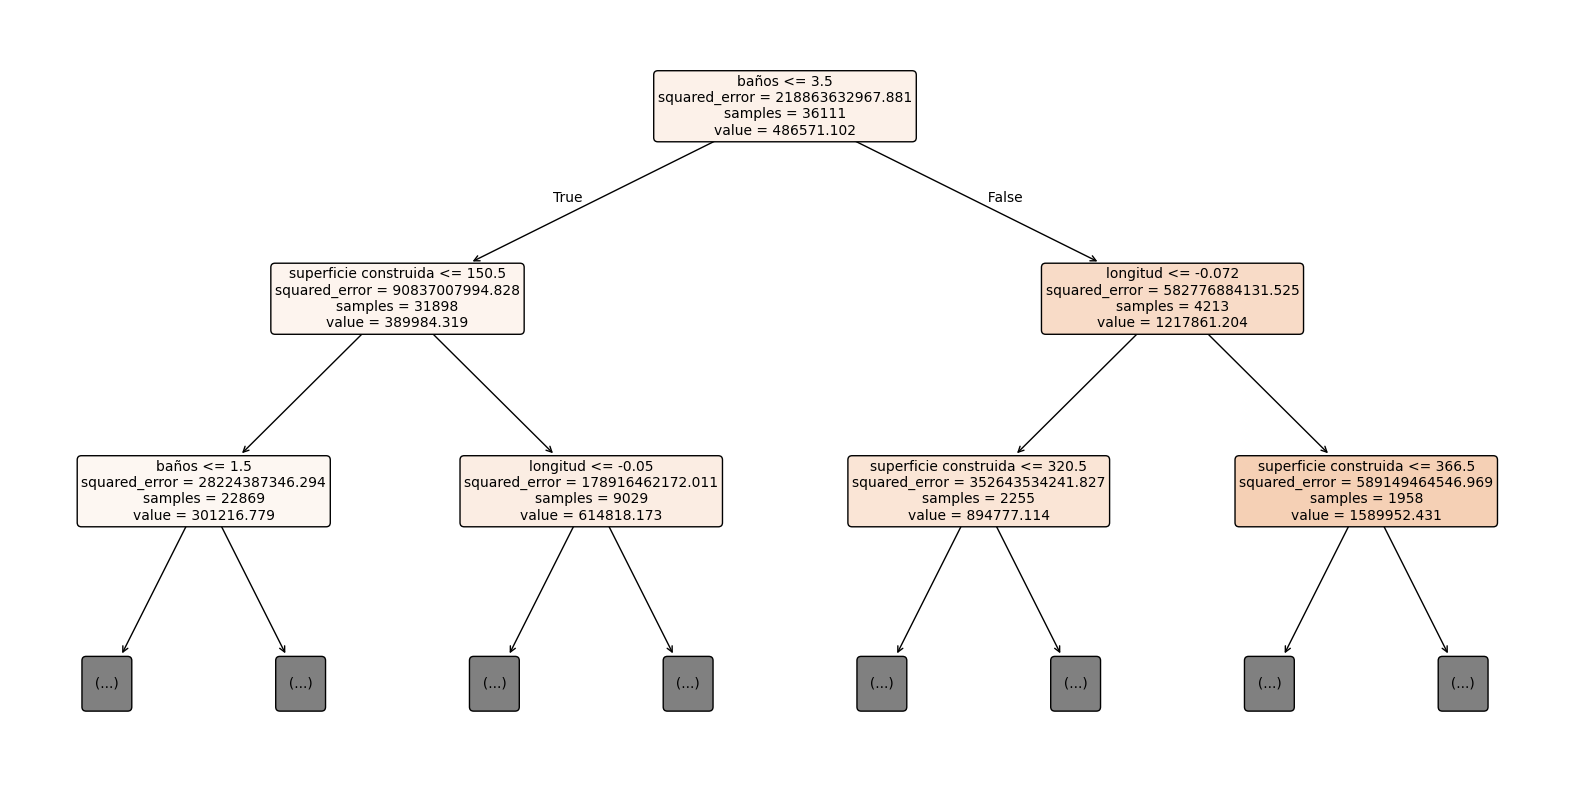

In [13]:
plt.figure(figsize=(20,10))
plot_tree(
    tree,
    feature_names=pisos_regresion_TreeDec.columns,
    filled=True,
    rounded=True,
    max_depth=2,
    fontsize=10
)
plt.show()

## Redes neuronales

In [ ]:
# Como las variables tienen que ser numericas o one hot, hacemos lo siguiente:

pisos_red1 = pisos.drop_duplicates()

# Separamos la columna precio del resto:

y_pisos_red1 = pisos_red1['precio']
pisos_red1 = pisos_red1.drop(columns=['precio'])

#y_pisos_red1 = temporal['precio']
#pisos_red1 = temporal.drop(columns=['precio'])

# Quitamos localidad:

pisos_red1 = pisos_red1.drop(columns=['localidad'])

pisos_red1 = pd.get_dummies(pisos_red1, columns=['tipo'], drop_first=True)
pisos_red1 = pd.get_dummies(pisos_red1, columns=['antiguedad'], drop_first=True)
pisos_red1 = pd.get_dummies(pisos_red1, columns=['conservacion'], drop_first=True)
pisos_red1 = pd.get_dummies(pisos_red1, columns=['terraza'], drop_first=True)
pisos_red1 = pd.get_dummies(pisos_red1, columns=['jardin'], drop_first=True)
pisos_red1 = pd.get_dummies(pisos_red1, columns=['orientacion'], drop_first=True)
pisos_red1 = pd.get_dummies(pisos_red1, columns=['garaje'], drop_first=True)
pisos_red1 = pd.get_dummies(pisos_red1, columns=['piscina'], drop_first=True)
pisos_red1 = pd.get_dummies(pisos_red1, columns=['aire_acondicionado'], drop_first=True)
pisos_red1 = pd.get_dummies(pisos_red1, columns=['trastero'], drop_first=True)
pisos_red1 = pd.get_dummies(pisos_red1, columns=['ascensor'], drop_first=True)
pisos_red1 = pd.get_dummies(pisos_red1, columns=['planta'], drop_first=True)

### Pruebas iniciales

#### Red 1

In [ ]:
# Intento 1

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# =====================================================================
# 1. PREPARACIÓN DE LOS DATOS
# =====================================================================

# SOLUCIÓN CRÍTICA: Forzar el DataFrame a float32. Esto convierte automáticamente
# todas las columnas booleanas (True/False) en valores numéricos reales (1.0 y 0.0)
# antes de intentar extraer la matriz de NumPy.
pisos_red1 = pisos_red1.astype(np.float32)

# X tomará las 67 columnas predictoras limpias, e y tomará la columna de precio.
X = pisos_red1.values
y = y_pisos_red1.values.astype(np.float32) # También aseguramos el precio como float

# Aplicar transformación logarítmica al precio.
y_log = np.log1p(y)

# Separación en conjunto de Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

# ESCALADO CONTROLADO: Seleccionamos exactamente tus 5 columnas float64 continuas.
columnas_continuas = ['latitud', 'longitud', 'superficie_construida', 'habitaciones', 'banyos']
indices_continuas = [pisos_red1.columns.get_loc(col) for col in columnas_continuas]

# Aplicamos el escalador solo sobre esas 5 columnas
scaler = StandardScaler()
X_train[:, indices_continuas] = scaler.fit_transform(X_train[:, indices_continuas])
X_test[:, indices_continuas] = scaler.transform(X_test[:, indices_continuas])

# Convertir los arrays de NumPy a tensores de PyTorch (Ahora funcionará sin problemas)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


# =====================================================================
# 2. DEFINICIÓN DE LA ARQUITECTURA DE LA RED NEURONAL
# =====================================================================

class RedPreciosVivienda(nn.Module):
    def __init__(self, input_dim):
        super(RedPreciosVivienda, self).__init__()
        # Definimos una estructura sencilla de 3 capas densas
        self.red = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(p=0.1),  # Evita el sobreajuste causado por las 67 columnas
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)    # Una única neurona de salida (el precio estimado)
        )

    def forward(self, x):
        return self.red(x)

# Inicializar el modelo con las 67 dimensiones de entrada
model = RedPreciosVivienda(input_dim=67)


# =====================================================================
# 3. CONFIGURACIÓN DEL OPTIMIZADOR Y FUNCIÓN DE PÉRDIDA
# =====================================================================

criterion = nn.MSELoss() # Pérdida de Error Cuadrático Medio
optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)


# =====================================================================
# 4. BUCLE DE ENTRENAMIENTO (TRAINING LOOP)
# =====================================================================

epochs = 150
print("--- Iniciando el Entrenamiento de la Red ---")

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad() # Limpiar gradientes del paso anterior

    # Paso hacia adelante (Forward pass)
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)

    # Paso hacia atrás (Backward pass y optimización)
    loss.backward()
    optimizer.step()

    # Imprimir el progreso cada 15 épocas
    if (epoch + 1) % 15 == 0 or epoch == 0:
        print(f"Época [{epoch+1}/{epochs}] -> Pérdida (MSE en log): {loss.item():.4f}")


# =====================================================================
# 5. EVALUACIÓN Y CÁLCULO DE MÉTRICAS (R², MSE, MAPE)
# =====================================================================

model.eval() # Modo evaluación (desactiva Dropout)
with torch.no_grad():
    predicciones_log = model(X_test_t).numpy()

# REVERTIR LA TRANSFORMACIÓN LOGARÍTMICA
y_test_real = np.expm1(y_test)
predicciones_real = np.expm1(predicciones_log)

# Calcular las métricas solicitadas (Corregida variable en MAPE)
r2 = r2_score(y_test_real, predicciones_real)
mse = mean_squared_error(y_test_real, predicciones_real)
mape = mean_absolute_percentage_error(y_test_real, predicciones_real) * 100 # En formato porcentaje (%)

print("\n==================================================")
print("       MÉTRICAS FINALES (DATOS DE TEST)          ")
print("==================================================")
print(f"R² (Coeficiente de Determinación): {r2:.4f}")
print(f"MSE (Error Cuadrático Medio):      {mse:,.2f}")
print(f"MAPE (Error Porcentual Medio):     {mape:.2f}%")
print("==================================================")

--- Iniciando el Entrenamiento de la Red ---
Época [1/250] -> Pérdida (MSE en log): 171.2616
Época [15/250] -> Pérdida (MSE en log): 153.4601
Época [30/250] -> Pérdida (MSE en log): 59.5236
Época [45/250] -> Pérdida (MSE en log): 17.2297
Época [60/250] -> Pérdida (MSE en log): 5.7130
Época [75/250] -> Pérdida (MSE en log): 2.9909
Época [90/250] -> Pérdida (MSE en log): 2.2290
Época [105/250] -> Pérdida (MSE en log): 1.9169
Época [120/250] -> Pérdida (MSE en log): 1.6913
Época [135/250] -> Pérdida (MSE en log): 1.5769
Época [150/250] -> Pérdida (MSE en log): 1.4734
Época [165/250] -> Pérdida (MSE en log): 1.3974
Época [180/250] -> Pérdida (MSE en log): 1.3750
Época [195/250] -> Pérdida (MSE en log): 1.3418
Época [210/250] -> Pérdida (MSE en log): 1.2720
Época [225/250] -> Pérdida (MSE en log): 1.2585
Época [240/250] -> Pérdida (MSE en log): 1.2377

       MÉTRICAS FINALES (DATOS DE TEST)          
R² (Coeficiente de Determinación): 0.4753
MSE (Error Cuadrático Medio):      114,187,591,6

#### Red 2

Cambiamos el lr y metemos mas hidden channel y dropout

In [ ]:
# Intento 2

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# =====================================================================
# 1. PREPARACIÓN DE LOS DATOS
# =====================================================================

pisos_red1 = pisos_red1.astype(np.float32)

X = pisos_red1.values
y = y_pisos_red1.values.astype(np.float32)

y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

columnas_continuas = ['latitud', 'longitud', 'superficie_construida', 'habitaciones', 'banyos']
indices_continuas = [pisos_red1.columns.get_loc(col) for col in columnas_continuas]

scaler = StandardScaler()
X_train[:, indices_continuas] = scaler.fit_transform(X_train[:, indices_continuas])
X_test[:, indices_continuas] = scaler.transform(X_test[:, indices_continuas])

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


# =====================================================================
# 2. DEFINICIÓN DE LA ARQUITECTURA DE LA RED NEURONAL
# =====================================================================

class RedPreciosVivienda(nn.Module):
    def __init__(self, input_dim):
        super(RedPreciosVivienda, self).__init__()
        self.red = nn.Sequential(
          nn.Linear(input_dim, 128),
          nn.ReLU(),
          nn.Dropout(p=0.2),
          nn.Linear(128, 64),
          nn.ReLU(),
          nn.Dropout(p=0.1),
          nn.Linear(64, 32),
          nn.ReLU(),
          nn.Linear(32, 1)
          )

    def forward(self, x):
        return self.red(x)

model = RedPreciosVivienda(input_dim=67)


# =====================================================================
# 3. CONFIGURACIÓN DEL OPTIMIZADOR Y FUNCIÓN DE PÉRDIDA (MAPE)
# =====================================================================

class MAPELossRealSpace(nn.Module):
    """
    Calcula el MAPE revirtiendo la transformación logarítmica (log1p -> expm1)
    para optimizar el error porcentual real en euros.
    """
    def __init__(self, eps=1e-8):
        super(MAPELossRealSpace, self).__init__()
        self.eps = eps # Pequeño valor para evitar divisiones por cero

    def forward(self, pred_log, target_log):
        # Revertir logaritmo para obtener los precios reales en euros
        pred_real = torch.expm1(pred_log)
        target_real = torch.expm1(target_log)

        # Calcular el error porcentual absoluto
        loss = torch.abs((target_real - pred_real) / (target_real + self.eps))
        return torch.mean(loss) * 100

# Reemplazamos nn.MSELoss() por nuestra nueva pérdida personalizada
criterion = MAPELossRealSpace()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)


# =====================================================================
# 4. BUCLE DE ENTRENAMIENTO (TRAINING LOOP)
# =====================================================================

epochs = 300
print("--- Iniciando el Entrenamiento de la Red ---")

for epoch in range(epochs):
    # --- FASE DE ENTRENAMIENTO ---
    model.train()
    optimizer.zero_grad()

    outputs_train = model(X_train_t)
    loss_train = criterion(outputs_train, y_train_t)

    loss_train.backward()
    optimizer.step()

    # --- FASE DE EVALUACIÓN EN TIEMPO REAL (TEST) ---
    # Imprimimos y calculamos el test de forma controlada cada 15 épocas
    if (epoch + 1) % 20 == 0 or epoch == 0:
        model.eval() # Cambiar a modo evaluación (desactiva Dropout)
        with torch.no_grad():
            outputs_test = model(X_test_t)
            loss_test = criterion(outputs_test, y_test_t)

        print(f"Época [{epoch+1}/{epochs}] -> Pérdida Train (MAPE): {loss_train.item():.2f}% | Pérdida Test (MAPE): {loss_test.item():.2f}%")


# =====================================================================
# 5. EVALUACIÓN Y CÁLCULO DE MÉTRICAS FINALES
# =====================================================================

model.eval()
with torch.no_grad():
    predicciones_log = model(X_test_t).numpy()

y_test_real = np.expm1(y_test)
predicciones_real = np.expm1(predicciones_log)

r2 = r2_score(y_test_real, predicciones_real)
mse = mean_squared_error(y_test_real, predicciones_real)
mape = mean_absolute_percentage_error(y_test_real, predicciones_real) * 100

print("\n==================================================")
print("       MÉTRICAS FINALES (DATOS DE TEST)          ")
print("==================================================")
print(f"R² (Coeficiente de Determinación): {r2:.4f}")
print(f"MSE (Error Cuadrático Medio):      {mse:,.2f}")
print(f"MAPE (Error Porcentual Medio):     {mape:.2f}%")
print("==================================================")

--- Iniciando el Entrenamiento de la Red ---
Época [1/300] -> Pérdida Train (MAPE): 100.00% | Pérdida Test (MAPE): 100.00%
Época [15/300] -> Pérdida Train (MAPE): 100.00% | Pérdida Test (MAPE): 100.00%
Época [30/300] -> Pérdida Train (MAPE): 100.00% | Pérdida Test (MAPE): 100.00%
Época [45/300] -> Pérdida Train (MAPE): 100.00% | Pérdida Test (MAPE): 100.00%
Época [60/300] -> Pérdida Train (MAPE): 100.00% | Pérdida Test (MAPE): 100.00%
Época [75/300] -> Pérdida Train (MAPE): 100.00% | Pérdida Test (MAPE): 100.00%
Época [90/300] -> Pérdida Train (MAPE): 100.04% | Pérdida Test (MAPE): 99.96%
Época [105/300] -> Pérdida Train (MAPE): 96.98% | Pérdida Test (MAPE): 97.69%
Época [120/300] -> Pérdida Train (MAPE): 94.90% | Pérdida Test (MAPE): 92.74%
Época [135/300] -> Pérdida Train (MAPE): 90.47% | Pérdida Test (MAPE): 86.62%
Época [150/300] -> Pérdida Train (MAPE): 75.56% | Pérdida Test (MAPE): 67.13%
Época [165/300] -> Pérdida Train (MAPE): 68.87% | Pérdida Test (MAPE): 57.56%
Época [180/300

#### Red 3

Metemos Mini lotes

In [ ]:
# Intento 4 - Optimización Estable en Espacio Logarítmico

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# =====================================================================
# 1. PREPARACIÓN DE LOS DATOS
# =====================================================================

pisos_red1 = pisos_red1.astype(np.float32)

X = pisos_red1.values
y = y_pisos_red1.values.astype(np.float32)

y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

columnas_continuas = ['latitud', 'longitud', 'superficie_construida', 'habitaciones', 'banyos']
indices_continuas = [pisos_red1.columns.get_loc(col) for col in columnas_continuas]

scaler = StandardScaler()
X_train[:, indices_continuas] = scaler.fit_transform(X_train[:, indices_continuas])
X_test[:, indices_continuas] = scaler.transform(X_test[:, indices_continuas])

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

batch_size = 128
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)


# =====================================================================
# 2. DEFINICIÓN DE LA ARQUITECTURA DE LA RED NEURONAL
# =====================================================================

class RedPreciosVivienda(nn.Module):
    def __init__(self, input_dim):
        super(RedPreciosVivienda, self).__init__()
        # Mantenemos una arquitectura intermedia y protegida contra overfitting
        self.red = nn.Sequential(
          nn.Linear(input_dim, 128),
          nn.ReLU(),
          nn.Dropout(p=0.3),
          nn.Linear(128, 64),
          nn.ReLU(),
          nn.Dropout(p=0.2),
          nn.Linear(64, 32),
          nn.ReLU(),
          nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.red(x)

model = RedPreciosVivienda(input_dim=67)


# =====================================================================
# 3. CONFIGURACIÓN DEL OPTIMIZADOR Y FUNCIÓN DE PÉRDIDA
# =====================================================================

# SOLUCIÓN: Usamos L1 Loss en el espacio logarítmico para garantizar estabilidad absoluta
criterion_train = nn.L1Loss()

# Mantenemos esta función auxiliar solo para medir el MAPE real en los prints
def calcular_mape_real(pred_log, target_log, eps=1e-8):
    pred_real = torch.expm1(pred_log)
    target_real = torch.expm1(target_log)
    loss = torch.abs((target_real - pred_real) / (target_real + eps))
    return torch.mean(loss) * 100

optimizer = optim.Adam(model.parameters(), lr=0.002, weight_decay=1e-4)


# =====================================================================
# 4. BUCLE DE ENTRENAMIENTO (TRAINING LOOP CON MINILOTES)
# =====================================================================

epochs = 200 # Con minilotes y L1, 200 épocas deberían ser más que suficientes
print("--- Iniciando el Entrenamiento de la Red ---")

for epoch in range(epochs):
    # --- FASE DE ENTRENAMIENTO ---
    model.train()
    loss_acumulada_mape = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        outputs_batch = model(X_batch)

        # Optimizamos basándonos en L1 (estable y rápido)
        loss_batch = criterion_train(outputs_batch, y_batch)
        loss_batch.backward()
        optimizer.step()

        # Calculamos el MAPE real de este bloque para mostrarlo en la consola
        with torch.no_grad():
            mape_batch = calcular_mape_real(outputs_batch, y_batch)
            loss_acumulada_mape += mape_batch.item() * X_batch.size(0)

    # MAPE medio de todo el conjunto de entrenamiento en esta época
    mape_train_total = loss_acumulada_mape / len(train_loader.dataset)

    # --- FASE DE EVALUACIÓN EN TIEMPO REAL (TEST) ---
    if (epoch + 1) % 15 == 0 or epoch == 0:
        model.eval()
        with torch.no_grad():
            outputs_test = model(X_test_t)
            mape_test = calcular_mape_real(outputs_test, y_test_t)

        print(f"Época [{epoch+1}/{epochs}] -> Pérdida Train (MAPE): {mape_train_total:.2f}% | Pérdida Test (MAPE): {mape_test.item():.2f}%")


# =====================================================================
# 5. EVALUACIÓN Y CÁLCULO DE MÉTRICAS FINALES
# =====================================================================

model.eval()
with torch.no_grad():
    predicciones_log = model(X_test_t).numpy()

y_test_real = np.expm1(y_test)
predicciones_real = np.expm1(predicciones_log)

r2 = r2_score(y_test_real, predicciones_real)
mse = mean_squared_error(y_test_real, predicciones_real)
mape = mean_absolute_percentage_error(y_test_real, predicciones_real) * 100

print("\n==================================================")
print("       MÉTRICAS FINALES (DATOS DE TEST)           ")
print("==================================================")
print(f"R² (Coeficiente de Determinación): {r2:.4f}")
print(f"MSE (Error Cuadrático Medio):      {mse:,.2f}")
print(f"MAPE (Error Porcentual Medio):     {mape:.2f}%")
print("==================================================")

--- Iniciando el Entrenamiento de la Red ---
Época [1/200] -> Pérdida Train (MAPE): inf% | Pérdida Test (MAPE): 47.38%
Época [15/200] -> Pérdida Train (MAPE): 30.62% | Pérdida Test (MAPE): 27.72%
Época [30/200] -> Pérdida Train (MAPE): 28.66% | Pérdida Test (MAPE): 25.15%
Época [45/200] -> Pérdida Train (MAPE): 28.04% | Pérdida Test (MAPE): 26.11%
Época [60/200] -> Pérdida Train (MAPE): 27.12% | Pérdida Test (MAPE): 26.35%
Época [75/200] -> Pérdida Train (MAPE): 9919304.72% | Pérdida Test (MAPE): 25.34%
Época [90/200] -> Pérdida Train (MAPE): 26.73% | Pérdida Test (MAPE): 25.12%
Época [105/200] -> Pérdida Train (MAPE): 30.78% | Pérdida Test (MAPE): 24.33%
Época [120/200] -> Pérdida Train (MAPE): 27.31% | Pérdida Test (MAPE): 25.00%
Época [135/200] -> Pérdida Train (MAPE): 27.03% | Pérdida Test (MAPE): 25.71%
Época [150/200] -> Pérdida Train (MAPE): 26.38% | Pérdida Test (MAPE): 25.19%
Época [165/200] -> Pérdida Train (MAPE): 26.37% | Pérdida Test (MAPE): 24.49%
Época [180/200] -> Pérdi

### Inicio de una red compleja

#### Red 1

La idea es, crear una red neuronal muy simple y empezar a añadirle cosas, para entenderla bien

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split

# =========================
# 1. PREPARAR LOS DATOS
# =========================

pisos_red1 = pisos_red1.astype(np.float32)

X = pisos_red1.values
y = y_pisos_red1.values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# =========================
# 2. MODELO
# =========================

class RedSimple(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)

input_dim = X.shape[1]
modelo = RedSimple(input_dim)

# =========================
# 3. LOSS + OPTIMIZADOR
# =========================

criterio = nn.MSELoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.001)

# =========================
# 4. ENTRENAMIENTO
# =========================

epochs = 100

for epoch in range(epochs):

    # ===== TRAIN =====
    modelo.train()

    pred_train = modelo(X_train_t)
    loss = criterio(pred_train, y_train_t)

    optimizador.zero_grad()
    loss.backward()
    optimizador.step()

    # ===== MÉTRICAS CADA 10 ÉPOCAS =====
    if epoch % 10 == 0:

        modelo.eval()

        with torch.no_grad():
            # Train
            pred_train = modelo(X_train_t)
            y_train_np = y_train_t.numpy()
            pred_train_np = pred_train.numpy()

            r2_train = r2_score(y_train_np, pred_train_np)
            mse_train = mean_squared_error(y_train_np, pred_train_np)
            mape_train = mean_absolute_percentage_error(y_train_np, pred_train_np)

            # Test
            pred_test = modelo(X_test_t)
            y_test_np = y_test_t.numpy()
            pred_test_np = pred_test.numpy()

            r2_test = r2_score(y_test_np, pred_test_np)
            mse_test = mean_squared_error(y_test_np, pred_test_np)
            mape_test = mean_absolute_percentage_error(y_test_np, pred_test_np)

        print(f"Epoch {epoch}")
        print(f"Loss (train): {loss.item():.4f}")
        print(f"TRAIN -> R2: {r2_train:.4f} | MSE: {mse_train:.4f} | MAPE: {mape_train:.4f}")
        print(f"TEST  -> R2: {r2_test:.4f} | MSE: {mse_test:.4f} | MAPE: {mape_test:.4f}")
        print("----------------------")

# =========================
# 5. RESULTADO FINAL
# =========================

modelo.eval()

with torch.no_grad():
    pred_train_final = modelo(X_train_t).numpy()
    pred_test_final = modelo(X_test_t).numpy()

# Métricas finales
r2_train = r2_score(y_train, pred_train_final)
r2_test = r2_score(y_test, pred_test_final)

mse_train = mean_squared_error(y_train, pred_train_final)
mse_test = mean_squared_error(y_test, pred_test_final)

mape_train = mean_absolute_percentage_error(y_train, pred_train_final)
mape_test = mean_absolute_percentage_error(y_test, pred_test_final)

print("\n=== RESULTADOS FINALES ===")
print(f"TRAIN -> R2: {r2_train:.4f} | MSE: {mse_train:.4f} | MAPE: {mape_train:.4f}")
print(f"TEST  -> R2: {r2_test:.4f} | MSE: {mse_test:.4f} | MAPE: {mape_test:.4f}")

Epoch 0
Loss (train): 454240010240.0000
TRAIN -> R2: -1.0929 | MSE: 454239780864.0000 | MAPE: 0.9999
TEST  -> R2: -1.0890 | MSE: 454654754816.0000 | MAPE: 0.9999
----------------------
Epoch 10
Loss (train): 454237323264.0000
TRAIN -> R2: -1.0929 | MSE: 454237028352.0000 | MAPE: 0.9999
TEST  -> R2: -1.0890 | MSE: 454652002304.0000 | MAPE: 0.9999
----------------------
Epoch 20
Loss (train): 454234603520.0000
TRAIN -> R2: -1.0928 | MSE: 454234308608.0000 | MAPE: 0.9999
TEST  -> R2: -1.0890 | MSE: 454649249792.0000 | MAPE: 0.9999
----------------------
Epoch 30
Loss (train): 454231851008.0000
TRAIN -> R2: -1.0928 | MSE: 454231588864.0000 | MAPE: 0.9999
TEST  -> R2: -1.0889 | MSE: 454646464512.0000 | MAPE: 0.9999
----------------------
Epoch 40
Loss (train): 454229131264.0000
TRAIN -> R2: -1.0928 | MSE: 454228836352.0000 | MAPE: 0.9999
TEST  -> R2: -1.0889 | MSE: 454643810304.0000 | MAPE: 0.9999
----------------------
Epoch 50
Loss (train): 454226411520.0000
TRAIN -> R2: -1.0928 | MSE: 45

#### Red 2 (Escalamos los datos)

Un escalado es totalmente necesario, ya que tenemos valores muy altos y las redes neuronales empiezan con valores más pequeños. Se lo aplicamos al precio y a las variables continuas (latitud, longitud, superficie_construida)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split

# =========================
# 1. PREPARAR LOS DATOS
# =========================

pisos_red1 = pisos_red1.astype(np.float32)

X = pisos_red1.values
y = y_pisos_red1.values.astype(np.float32)

y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

columnas_continuas = ['latitud', 'longitud', 'superficie_construida', 'habitaciones', 'banyos']
indices_continuas = [pisos_red1.columns.get_loc(col) for col in columnas_continuas]

scaler = StandardScaler()
X_train[:, indices_continuas] = scaler.fit_transform(X_train[:, indices_continuas])
X_test[:, indices_continuas] = scaler.transform(X_test[:, indices_continuas])

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# =========================
# 2. MODELO
# =========================

class RedSimple(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)

input_dim = X.shape[1]
modelo = RedSimple(input_dim)

# =========================
# 3. LOSS + OPTIMIZADOR
# =========================

criterio = nn.MSELoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.001)

# =========================
# 4. ENTRENAMIENTO
# =========================

epochs = 100

for epoch in range(epochs):

    # ===== TRAIN =====
    modelo.train()

    pred_train = modelo(X_train_t)
    loss = criterio(pred_train, y_train_t)

    optimizador.zero_grad()
    loss.backward()
    optimizador.step()

    # ===== MÉTRICAS CADA 10 ÉPOCAS =====
    if epoch % 10 == 0:

        modelo.eval()

        with torch.no_grad():
            # Train
            pred_train = modelo(X_train_t)
            y_train_real = np.expm1(y_train_t.numpy())
            pred_train_real = np.expm1(pred_train.numpy())

            r2_train = r2_score(y_train_real, pred_train_real)
            mse_train = mean_squared_error(y_train_real, pred_train_real)
            mape_train = mean_absolute_percentage_error(y_train_real, pred_train_real)

            # Test
            pred_test = modelo(X_test_t)
            y_test_real = np.expm1(y_test_t.numpy())
            pred_test_real = np.expm1(pred_test.numpy())

            r2_test = r2_score(y_test_real, pred_test_real)
            mse_test = mean_squared_error(y_test_real, pred_test_real)
            mape_test = mean_absolute_percentage_error(y_test_real, pred_test_real)

        print(f"Epoch {epoch}")
        print(f"Loss (train): {loss.item():.4f}")
        print(f"TRAIN -> R2: {r2_train:.4f} | MSE: {mse_train:.4f} | MAPE: {mape_train:.4f}")
        print(f"TEST  -> R2: {r2_test:.4f} | MSE: {mse_test:.4f} | MAPE: {mape_test:.4f}")
        print("----------------------")

# =========================
# 5. RESULTADO FINAL
# =========================

modelo.eval()

with torch.no_grad():
    pred_train_real_final = np.expm1(modelo(X_train_t).numpy())
    pred_test_real_final = np.expm1(modelo(X_test_t).numpy())

# Métricas finales

y_train_real_final = np.expm1(y_train)
y_test_real_final = np.expm1(y_test)

r2_train = r2_score(y_train_real_final, pred_train_real_final)
r2_test = r2_score(y_test_real_final, pred_test_real_final)

mse_train = mean_squared_error(y_train_real_final, pred_train_real_final)
mse_test = mean_squared_error(y_test_real_final, pred_test_real_final)

mape_train = mean_absolute_percentage_error(y_train_real_final, pred_train_real_final)
mape_test = mean_absolute_percentage_error(y_test_real_final, pred_test_real_final)

print("\n=== RESULTADOS FINALES ===")
print(f"TRAIN -> R2: {r2_train:.4f} | MSE: {mse_train:.4f} | MAPE: {mape_train:.4f}")
print(f"TEST  -> R2: {r2_test:.4f} | MSE: {mse_test:.4f} | MAPE: {mape_test:.4f}")

Epoch 0
Loss (train): 166.2420
TRAIN -> R2: -1.0930 | MSE: 454261669888.0000 | MAPE: 1.0000
TEST  -> R2: -1.0891 | MSE: 454676742144.0000 | MAPE: 1.0000
----------------------
Epoch 10
Loss (train): 164.1657
TRAIN -> R2: -1.0930 | MSE: 454261571584.0000 | MAPE: 1.0000
TEST  -> R2: -1.0891 | MSE: 454676643840.0000 | MAPE: 1.0000
----------------------
Epoch 20
Loss (train): 162.1081
TRAIN -> R2: -1.0930 | MSE: 454261473280.0000 | MAPE: 1.0000
TEST  -> R2: -1.0891 | MSE: 454676480000.0000 | MAPE: 1.0000
----------------------
Epoch 30
Loss (train): 160.0711
TRAIN -> R2: -1.0930 | MSE: 454261276672.0000 | MAPE: 1.0000
TEST  -> R2: -1.0891 | MSE: 454676348928.0000 | MAPE: 1.0000
----------------------
Epoch 40
Loss (train): 158.0556
TRAIN -> R2: -1.0930 | MSE: 454261112832.0000 | MAPE: 1.0000
TEST  -> R2: -1.0891 | MSE: 454676217856.0000 | MAPE: 1.0000
----------------------
Epoch 50
Loss (train): 156.0621
TRAIN -> R2: -1.0930 | MSE: 454260981760.0000 | MAPE: 1.0000
TEST  -> R2: -1.0891 | 

Le falta capacidad, vamos a aumentar las capas.

#### Red 3 (Aumentamos el número de capas)

El siguiente paso natural y necesario es aumentar el número de capas

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split

# =========================
# 1. PREPARAR LOS DATOS
# =========================

pisos_red1 = pisos_red1.astype(np.float32)

X = pisos_red1.values
y = y_pisos_red1.values.astype(np.float32)

y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

columnas_continuas = ['latitud', 'longitud', 'superficie_construida', 'habitaciones', 'banyos']
indices_continuas = [pisos_red1.columns.get_loc(col) for col in columnas_continuas]

scaler = StandardScaler()
X_train[:, indices_continuas] = scaler.fit_transform(X_train[:, indices_continuas])
X_test[:, indices_continuas] = scaler.transform(X_test[:, indices_continuas])

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# =========================
# 2. MODELO
# =========================

class RedViviendas(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.red = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.red(x)

input_dim = X.shape[1]
modelo = RedViviendas(input_dim)

# =========================
# 3. LOSS + OPTIMIZADOR
# =========================

criterio = nn.MSELoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.001)

# =========================
# 4. ENTRENAMIENTO
# =========================

epochs = 100

for epoch in range(epochs):

    # ===== TRAIN =====
    modelo.train()

    pred_train = modelo(X_train_t)
    loss = criterio(pred_train, y_train_t)

    optimizador.zero_grad()
    loss.backward()
    optimizador.step()

    # ===== MÉTRICAS CADA 10 ÉPOCAS =====
    if epoch % 10 == 0:

        modelo.eval()

        with torch.no_grad():
            # Train
            pred_train = modelo(X_train_t)
            y_train_real = y_train_t.numpy()
            pred_train_real = pred_train.numpy()

            r2_train = r2_score(y_train_real, pred_train_real)
            mse_train = mean_squared_error(y_train_real, pred_train_real)
            mape_train = mean_absolute_percentage_error(y_train_real, pred_train_real)

            # Test
            pred_test = modelo(X_test_t)
            y_test_real = y_test_t.numpy()
            pred_test_real = pred_test.numpy()

            r2_test = r2_score(y_test_real, pred_test_real)
            mse_test = mean_squared_error(y_test_real, pred_test_real)
            mape_test = mean_absolute_percentage_error(y_test_real, pred_test_real)

        print(f"Epoch {epoch}")
        print(f"Loss (train): {loss.item():.4f}")
        print(f"TRAIN -> R2: {r2_train:.4f} | MSE: {mse_train:.4f} | MAPE: {mape_train:.4f}")
        print(f"TEST  -> R2: {r2_test:.4f} | MSE: {mse_test:.4f} | MAPE: {mape_test:.4f}")
        print("----------------------")

# =========================
# 5. RESULTADO FINAL
# =========================

modelo.eval()

with torch.no_grad():
    pred_train_real_final = np.expm1(modelo(X_train_t).numpy())
    pred_test_real_final = np.expm1(modelo(X_test_t).numpy())

# Métricas finales

y_train_real_final = np.expm1(y_train)
y_test_real_final = np.expm1(y_test)

r2_train = r2_score(y_train_real_final, pred_train_real_final)
r2_test = r2_score(y_test_real_final, pred_test_real_final)

mse_train = mean_squared_error(y_train_real_final, pred_train_real_final)
mse_test = mean_squared_error(y_test_real_final, pred_test_real_final)

mape_train = mean_absolute_percentage_error(y_train_real_final, pred_train_real_final)
mape_test = mean_absolute_percentage_error(y_test_real_final, pred_test_real_final)

print("\n=== RESULTADOS FINALES ===")
print(f"TRAIN -> R2: {r2_train:.4f} | MSE: {mse_train:.4f} | MAPE: {mape_train:.4f}")
print(f"TEST  -> R2: {r2_test:.4f} | MSE: {mse_test:.4f} | MAPE: {mape_test:.4f}")

Epoch 0
Loss (train): 168.4045
TRAIN -> R2: -295.5511 | MSE: 167.8857 | MAPE: 1.0110
TEST  -> R2: -293.9840 | MSE: 167.8846 | MAPE: 1.0110
----------------------
Epoch 10
Loss (train): 163.5822
TRAIN -> R2: -287.1374 | MSE: 163.1225 | MAPE: 0.9966
TEST  -> R2: -285.6357 | MSE: 163.1333 | MAPE: 0.9966
----------------------
Epoch 20
Loss (train): 158.5277
TRAIN -> R2: -277.9218 | MSE: 157.9053 | MAPE: 0.9804
TEST  -> R2: -276.5078 | MSE: 157.9383 | MAPE: 0.9805
----------------------
Epoch 30
Loss (train): 150.4992
TRAIN -> R2: -262.9482 | MSE: 149.4283 | MAPE: 0.9537
TEST  -> R2: -261.6783 | MSE: 149.4985 | MAPE: 0.9539
----------------------
Epoch 40
Loss (train): 136.7982
TRAIN -> R2: -237.4936 | MSE: 135.0178 | MAPE: 0.9062
TEST  -> R2: -236.4518 | MSE: 135.1413 | MAPE: 0.9066
----------------------
Epoch 50
Loss (train): 115.1043
TRAIN -> R2: -197.6272 | MSE: 112.4483 | MAPE: 0.8261
TEST  -> R2: -196.9164 | MSE: 112.6404 | MAPE: 0.8267
----------------------
Epoch 60
Loss (train): 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1275: RuntimeWarning: overflow encountered in square
  numerator = xp.sum(weight * (y_true - y_pred) ** 2, axis=0)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:570: RuntimeWarning: overflow encountered in square
  output_errors = _average((y_true - y_pred) ** 2, axis=0, weights=sample_weight)


#### Red 4 (Añadimos regularización)

Nos da una advertencia porque la red es inestable y toma valores muy altos, Añadimos
```weight_decay``` al optimizardor para aplicar una regularización Ridge.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split

# =========================
# 1. PREPARAR LOS DATOS
# =========================

pisos_red1 = pisos_red1.astype(np.float32)

X = pisos_red1.values
y = y_pisos_red1.values.astype(np.float32)

y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

columnas_continuas = ['latitud', 'longitud', 'superficie_construida', 'habitaciones', 'banyos']
indices_continuas = [pisos_red1.columns.get_loc(col) for col in columnas_continuas]

scaler = StandardScaler()
X_train[:, indices_continuas] = scaler.fit_transform(X_train[:, indices_continuas])
X_test[:, indices_continuas] = scaler.transform(X_test[:, indices_continuas])

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# =========================
# 2. MODELO
# =========================

class RedViviendas(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.red = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.red(x)

input_dim = X.shape[1]
modelo = RedViviendas(input_dim)

# =========================
# 3. LOSS + OPTIMIZADOR
# =========================

criterio = nn.MSELoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 4. ENTRENAMIENTO
# =========================

epochs = 100

for epoch in range(epochs):

    # ===== TRAIN =====
    modelo.train()

    pred_train = modelo(X_train_t)
    loss = criterio(pred_train, y_train_t)

    optimizador.zero_grad()
    loss.backward()
    optimizador.step()

    # ===== MÉTRICAS CADA 10 ÉPOCAS =====
    if epoch % 10 == 0:

        modelo.eval()

        with torch.no_grad():
            # Train
            pred_train = modelo(X_train_t)
            y_train_real = y_train_t.numpy()
            pred_train_real = pred_train.numpy()

            r2_train = r2_score(y_train_real, pred_train_real)
            mse_train = mean_squared_error(y_train_real, pred_train_real)
            mape_train = mean_absolute_percentage_error(y_train_real, pred_train_real)

            # Test
            pred_test = modelo(X_test_t)
            y_test_real = y_test_t.numpy()
            pred_test_real = pred_test.numpy()

            r2_test = r2_score(y_test_real, pred_test_real)
            mse_test = mean_squared_error(y_test_real, pred_test_real)
            mape_test = mean_absolute_percentage_error(y_test_real, pred_test_real)

        print(f"Epoch {epoch}")
        print(f"Loss (train): {loss.item():.4f}")
        print(f"TRAIN -> R2: {r2_train:.4f} | MSE: {mse_train:.4f} | MAPE: {mape_train:.4f}")
        print(f"TEST  -> R2: {r2_test:.4f} | MSE: {mse_test:.4f} | MAPE: {mape_test:.4f}")
        print("----------------------")

# =========================
# 5. RESULTADO FINAL
# =========================

modelo.eval()

with torch.no_grad():
    pred_train_real_final = np.expm1(modelo(X_train_t).numpy())
    pred_test_real_final = np.expm1(modelo(X_test_t).numpy())

# Métricas finales

y_train_real_final = np.expm1(y_train)
y_test_real_final = np.expm1(y_test)

r2_train = r2_score(y_train_real_final, pred_train_real_final)
r2_test = r2_score(y_test_real_final, pred_test_real_final)

mse_train = mean_squared_error(y_train_real_final, pred_train_real_final)
mse_test = mean_squared_error(y_test_real_final, pred_test_real_final)

mape_train = mean_absolute_percentage_error(y_train_real_final, pred_train_real_final)
mape_test = mean_absolute_percentage_error(y_test_real_final, pred_test_real_final)

print("\n=== RESULTADOS FINALES ===")
print(f"TRAIN -> R2: {r2_train:.4f} | MSE: {mse_train:.4f} | MAPE: {mape_train:.4f}")
print(f"TEST  -> R2: {r2_test:.4f} | MSE: {mse_test:.4f} | MAPE: {mape_test:.4f}")

Epoch 0
Loss (train): 160.3116
TRAIN -> R2: -281.8312 | MSE: 160.1185 | MAPE: 0.9872
TEST  -> R2: -280.3397 | MSE: 160.1192 | MAPE: 0.9873
----------------------
Epoch 10
Loss (train): 158.2652
TRAIN -> R2: -278.1543 | MSE: 158.0369 | MAPE: 0.9809
TEST  -> R2: -276.6947 | MSE: 158.0447 | MAPE: 0.9809
----------------------
Epoch 20
Loss (train): 155.5649
TRAIN -> R2: -273.1956 | MSE: 155.2297 | MAPE: 0.9723
TEST  -> R2: -271.7686 | MSE: 155.2412 | MAPE: 0.9723
----------------------
Epoch 30
Loss (train): 151.4382
TRAIN -> R2: -265.5741 | MSE: 150.9149 | MAPE: 0.9589
TEST  -> R2: -264.1972 | MSE: 150.9320 | MAPE: 0.9590
----------------------
Epoch 40
Loss (train): 145.0000
TRAIN -> R2: -253.6953 | MSE: 144.1900 | MAPE: 0.9376
TEST  -> R2: -252.4020 | MSE: 144.2190 | MAPE: 0.9376
----------------------
Epoch 50
Loss (train): 135.2409
TRAIN -> R2: -235.7758 | MSE: 134.0453 | MAPE: 0.9041
TEST  -> R2: -234.6081 | MSE: 134.0919 | MAPE: 0.9043
----------------------
Epoch 60
Loss (train): 

Vemos como aunque los resultados en log son superiores a los de la red 3, los pesos son más estables, ya que al transformar a escala normal obtenemos un MAPE incluso menor que 1 (Comparado con 22, en la anterior red)

#### Red 5 (Aumento de épocas)

Vamos a aumentar en número de épocas a 4000

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import train_test_split

# =========================
# 1. PREPARAR LOS DATOS
# =========================

pisos_red1 = pisos_red1.astype(np.float32)

X = pisos_red1.values
y = y_pisos_red1.values.astype(np.float32)

y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

columnas_continuas = ['latitud', 'longitud', 'superficie_construida', 'habitaciones', 'banyos']
indices_continuas = [pisos_red1.columns.get_loc(col) for col in columnas_continuas]

scaler = StandardScaler()
X_train[:, indices_continuas] = scaler.fit_transform(X_train[:, indices_continuas])
X_test[:, indices_continuas] = scaler.transform(X_test[:, indices_continuas])

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_log_tensor = torch.tensor(y_train_log, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_log_tensor = torch.tensor(y_test_log, dtype=torch.float32).view(-1, 1)

# =========================
# 2. MODELO
# =========================

class RedViviendas(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.red = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.red(x)

input_dim = X.shape[1]
modelo = RedViviendas(input_dim)

# =========================
# 3. LOSS + OPTIMIZADOR
# =========================

criterio = nn.MSELoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 4. ENTRENAMIENTO
# =========================

epochs = 4001

for epoch in range(epochs):

    # ===== TRAIN =====
    modelo.train()

    pred_train = modelo(X_train_tensor)
    loss = criterio(pred_train, y_train_log_tensor)

    optimizador.zero_grad()
    loss.backward()
    optimizador.step()

    # ===== MÉTRICAS CADA n ÉPOCAS =====
    if epoch % 400 == 0:

        modelo.eval()

        with torch.no_grad():
            # Train
            pred_train_log = modelo(X_train_tensor)
            y_train_log_numpy = y_train_log_tensor.numpy()
            pred_train_log_numpy = pred_train_log.numpy()

            r2_train_log = r2_score(y_train_log_numpy, pred_train_log_numpy)
            mse_train_log = mean_squared_error(y_train_log_numpy, pred_train_log_numpy)
            mape_train_log = mean_absolute_percentage_error(y_train_log_numpy, pred_train_log_numpy)

            # Test
            pred_test_log = modelo(X_test_tensor)
            y_test_log_numpy = y_test_log_tensor.numpy()
            pred_test_log_numpy = pred_test_log.numpy()

            r2_test_log = r2_score(y_test_log_numpy, pred_test_log_numpy)
            mse_test_log = mean_squared_error(y_test_log_numpy, pred_test_log_numpy)
            mape_test_log = mean_absolute_percentage_error(y_test_log_numpy, pred_test_log_numpy)

        print(f"Epoch {epoch}")
        print(f"Loss (train): {loss.item():.5f}")
        print(f"TRAIN -> R2: {r2_train_log:.5f} | MSE: {mse_train_log:.5f} | MAPE: {mape_train_log:.5f}")
        print(f"TEST  -> R2: {r2_test_log:.5f} | MSE: {mse_test_log:.5f} | MAPE: {mape_test_log:.5f}")
        print("----------------------")

Epoch 0
Loss (train): 160.28139
TRAIN -> R2: -281.59897 | MSE: 159.98705 | MAPE: 0.98689
TEST  -> R2: -280.07745 | MSE: 159.96996 | MAPE: 0.98685
----------------------
Epoch 400
Loss (train): 0.44197
TRAIN -> R2: 0.22135 | MSE: 0.44081 | MAPE: 0.03692
TEST  -> R2: 0.23986 | MSE: 0.43262 | MAPE: 0.03670
----------------------
Epoch 800
Loss (train): 0.19137
TRAIN -> R2: 0.66227 | MSE: 0.19120 | MAPE: 0.02478
TEST  -> R2: 0.66661 | MSE: 0.18974 | MAPE: 0.02456
----------------------
Epoch 1200
Loss (train): 0.16793
TRAIN -> R2: 0.70342 | MSE: 0.16790 | MAPE: 0.02348
TEST  -> R2: 0.70414 | MSE: 0.16839 | MAPE: 0.02320
----------------------
Epoch 1600
Loss (train): 0.14960
TRAIN -> R2: 0.73581 | MSE: 0.14956 | MAPE: 0.02228
TEST  -> R2: 0.73069 | MSE: 0.15327 | MAPE: 0.02225
----------------------
Epoch 2000
Loss (train): 0.13995
TRAIN -> R2: 0.75284 | MSE: 0.13993 | MAPE: 0.02172
TEST  -> R2: 0.74481 | MSE: 0.14524 | MAPE: 0.02184
----------------------
Epoch 2400
Loss (train): 0.13384


In [ ]:
# =========================
# 5. RESULTADO FINAL
# =========================

modelo.eval()

with torch.no_grad():
    pred_train_log_final = modelo(X_train_tensor).numpy()
    pred_test_log_final = modelo(X_test_tensor).numpy()

# Métricas finales (Con log)

y_train_log_final = y_train_log
y_test_log_final = y_test_log

r2_train_log = r2_score(y_train_log_final, pred_train_log_final)
r2_test_log = r2_score(y_test_log_final, pred_test_log_final)

mae_train_log = mean_absolute_error(y_train_log_final, pred_train_log_final)
mae_test_log = mean_absolute_error(y_test_log_final, pred_test_log_final)

mse_train_log = mean_squared_error(y_train_log_final, pred_train_log_final)
mse_test_log = mean_squared_error(y_test_log_final, pred_test_log_final)

mape_train_log = mean_absolute_percentage_error(y_train_log_final, pred_train_log_final)
mape_test_log = mean_absolute_percentage_error(y_test_log_final, pred_test_log_final)

print("\n=== RESULTADOS FINALES (Con log) ===")
print(f"TRAIN -> R2: {r2_train_log:.4f} | MAE: {mae_train_log:,.4f} € | MSE: {mse_train_log:.4f} | MAPE: {mape_train_log:.4f}")
print(f"TEST  -> R2: {r2_test_log:.4f} | MAE: {mae_test_log:,.4f} € | MSE: {mse_test_log:.4f} | MAPE: {mape_test_log:.4f}")


# Métricas finales (Sin log)

y_train_final = np.expm1(y_train_log)
pred_train_final = np.expm1(pred_train_log_final)

y_test_final = np.expm1(y_test_log)
pred_test_final = np.expm1(pred_test_log_final)

r2_train = r2_score(y_train_final, pred_train_final)
r2_test = r2_score(y_test_final, pred_test_final)

mae_train = mean_absolute_error(y_train_final, pred_train_final)
mae_test = mean_absolute_error(y_test_final, pred_test_final)

mse_train = mean_squared_error(y_train_final, pred_train_final)
mse_test = mean_squared_error(y_test_final, pred_test_final)

mape_train = mean_absolute_percentage_error(y_train_final, pred_train_final)
mape_test = mean_absolute_percentage_error(y_test_final, pred_test_final)

print("\n=== RESULTADOS FINALES (Sin log) ===")
print(f"TRAIN -> R2: {r2_train:.4f} | MAE: {mae_train:,.4f} € | MSE: {mse_train:.4f} | MAPE: {mape_train:.4f}")
print(f"TEST  -> R2: {r2_test:.4f} | MAE: {mae_test:,.4f} € | MSE: {mse_test:.4f} | MAPE: {mape_test:.4f}")


=== RESULTADOS FINALES (Con log) ===
TRAIN -> R2: 0.7770 | MAE: 0.2665 € | MSE: 0.1262 | MAPE: 0.0209
TEST  -> R2: 0.7716 | MAE: 0.2679 € | MSE: 0.1300 | MAPE: 0.0210

=== RESULTADOS FINALES (Sin log) ===
TRAIN -> R2: 0.6918 | MAE: 134,843.2031 € | MSE: 66883096576.0000 | MAPE: 0.2766
TEST  -> R2: 0.6776 | MAE: 135,511.4844 € | MSE: 70170050560.0000 | MAPE: 0.2770


Parece que el modelo no puede aprender mas aun asi, no tenemos sobreajuste lo cual es buen sintoma de que hay margen de mejora. Cosas a probar:
- Aumentar las hidden channel.
- Añadir una capa extra.
- Disminuimos regularización, pasar de 1e-4 a 1e-5, asi el modelo tiene menos restricciones.
- Modificar learning rate.

#### Red 6 (Aumentamos la complejidad)

Vamos a añadir una capa extra a la red y también vamos a aumentar el número de hidden channel:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import train_test_split

# =========================
# 1. PREPARAR LOS DATOS
# =========================

pisos_red1 = pisos_red1.astype(np.float32)

X = pisos_red1.values
y = y_pisos_red1.values.astype(np.float32)

y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

columnas_continuas = ['latitud', 'longitud', 'superficie_construida', 'habitaciones', 'banyos']
indices_continuas = [pisos_red1.columns.get_loc(col) for col in columnas_continuas]

scaler = StandardScaler()
X_train[:, indices_continuas] = scaler.fit_transform(X_train[:, indices_continuas])
X_test[:, indices_continuas] = scaler.transform(X_test[:, indices_continuas])

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_log_tensor = torch.tensor(y_train_log, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_log_tensor = torch.tensor(y_test_log, dtype=torch.float32).view(-1, 1)

# =========================
# 2. MODELO
# =========================

class RedViviendas(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.red = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.red(x)

input_dim = X.shape[1]
modelo = RedViviendas(input_dim)

# =========================
# 3. LOSS + OPTIMIZADOR
# =========================

criterio = nn.MSELoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 4. ENTRENAMIENTO
# =========================

epochs = 4001

for epoch in range(epochs):

    # ===== TRAIN =====
    modelo.train()

    pred_train = modelo(X_train_tensor)
    loss = criterio(pred_train, y_train_log_tensor)

    optimizador.zero_grad()
    loss.backward()
    optimizador.step()

    # ===== MÉTRICAS CADA n ÉPOCAS =====
    if epoch % 400 == 0:

        modelo.eval()

        with torch.no_grad():
            # Train
            pred_train_log = modelo(X_train_tensor)
            y_train_log_numpy = y_train_log_tensor.numpy()
            pred_train_log_numpy = pred_train_log.numpy()

            r2_train_log = r2_score(y_train_log_numpy, pred_train_log_numpy)
            mse_train_log = mean_squared_error(y_train_log_numpy, pred_train_log_numpy)
            mape_train_log = mean_absolute_percentage_error(y_train_log_numpy, pred_train_log_numpy)

            # Test
            pred_test_log = modelo(X_test_tensor)
            y_test_log_numpy = y_test_log_tensor.numpy()
            pred_test_log_numpy = pred_test_log.numpy()

            r2_test_log = r2_score(y_test_log_numpy, pred_test_log_numpy)
            mse_test_log = mean_squared_error(y_test_log_numpy, pred_test_log_numpy)
            mape_test_log = mean_absolute_percentage_error(y_test_log_numpy, pred_test_log_numpy)

        print(f"Epoch {epoch}")
        print(f"Loss (train): {loss.item():.5f}")
        print(f"TRAIN -> R2: {r2_train_log:.5f} | MSE: {mse_train_log:.5f} | MAPE: {mape_train_log:.5f}")
        print(f"TEST  -> R2: {r2_test_log:.5f} | MSE: {mse_test_log:.5f} | MAPE: {mape_test_log:.5f}")
        print("----------------------")

Epoch 0
Loss (train): 164.35321
TRAIN -> R2: -288.81030 | MSE: 164.06958 | MAPE: 0.99945
TEST  -> R2: -287.26791 | MSE: 164.06227 | MAPE: 0.99944
----------------------
Epoch 400
Loss (train): 0.41553
TRAIN -> R2: 0.26750 | MSE: 0.41469 | MAPE: 0.03607
TEST  -> R2: 0.27671 | MSE: 0.41165 | MAPE: 0.03606
----------------------
Epoch 800
Loss (train): 0.15078
TRAIN -> R2: 0.73376 | MSE: 0.15073 | MAPE: 0.02231
TEST  -> R2: 0.72610 | MSE: 0.15589 | MAPE: 0.02235
----------------------
Epoch 1200
Loss (train): 0.13923
TRAIN -> R2: 0.75409 | MSE: 0.13922 | MAPE: 0.02171
TEST  -> R2: 0.74282 | MSE: 0.14637 | MAPE: 0.02189
----------------------
Epoch 1600
Loss (train): 0.13407
TRAIN -> R2: 0.76321 | MSE: 0.13406 | MAPE: 0.02143
TEST  -> R2: 0.75167 | MSE: 0.14133 | MAPE: 0.02166
----------------------
Epoch 2000
Loss (train): 0.13036
TRAIN -> R2: 0.76974 | MSE: 0.13036 | MAPE: 0.02119
TEST  -> R2: 0.75869 | MSE: 0.13734 | MAPE: 0.02146
----------------------
Epoch 2400
Loss (train): 0.12678


In [ ]:
# =========================
# 5. RESULTADO FINAL
# =========================

modelo.eval()

with torch.no_grad():
    pred_train_log_final = modelo(X_train_tensor).numpy()
    pred_test_log_final = modelo(X_test_tensor).numpy()

# Métricas finales (Con log)

y_train_log_final = y_train_log
y_test_log_final = y_test_log

r2_train_log = r2_score(y_train_log_final, pred_train_log_final)
r2_test_log = r2_score(y_test_log_final, pred_test_log_final)

mae_train_log = mean_absolute_error(y_train_log_final, pred_train_log_final)
mae_test_log = mean_absolute_error(y_test_log_final, pred_test_log_final)

mse_train_log = mean_squared_error(y_train_log_final, pred_train_log_final)
mse_test_log = mean_squared_error(y_test_log_final, pred_test_log_final)

mape_train_log = mean_absolute_percentage_error(y_train_log_final, pred_train_log_final)
mape_test_log = mean_absolute_percentage_error(y_test_log_final, pred_test_log_final)

print("\n=== RESULTADOS FINALES (Con log) ===")
print(f"TRAIN -> R2: {r2_train_log:.5f} | MAE: {mae_train_log:,.5f} € | MSE: {mse_train_log:.5f} | MAPE: {mape_train_log:.5f}")
print(f"TEST  -> R2: {r2_test_log:.5f} | MAE: {mae_test_log:,.5f} € | MSE: {mse_test_log:.5f} | MAPE: {mape_test_log:.5f}")


# Métricas finales (Sin log)

y_train_final = np.expm1(y_train_log)
pred_train_final = np.expm1(pred_train_log_final)

y_test_final = np.expm1(y_test_log)
pred_test_final = np.expm1(pred_test_log_final)

r2_train = r2_score(y_train_final, pred_train_final)
r2_test = r2_score(y_test_final, pred_test_final)

mae_train = mean_absolute_error(y_train_final, pred_train_final)
mae_test = mean_absolute_error(y_test_final, pred_test_final)

mse_train = mean_squared_error(y_train_final, pred_train_final)
mse_test = mean_squared_error(y_test_final, pred_test_final)

mape_train = mean_absolute_percentage_error(y_train_final, pred_train_final)
mape_test = mean_absolute_percentage_error(y_test_final, pred_test_final)

print("\n=== RESULTADOS FINALES (Sin log) ===")
print(f"TRAIN -> R2: {r2_train:.5f} | MAE: {mae_train:,.5f} € | MSE: {mse_train:.5f} | MAPE: {mape_train:.5f}")
print(f"TEST  -> R2: {r2_test:.5f} | MAE: {mae_test:,.5f} € | MSE: {mse_test:.5f} | MAPE: {mape_test:.5f}")


=== RESULTADOS FINALES (Con log) ===
TRAIN -> R2: 0.8011 | MAE: 0.2524 € | MSE: 0.1126 | MAPE: 0.0198
TEST  -> R2: 0.7908 | MAE: 0.2569 € | MSE: 0.1191 | MAPE: 0.0201

=== RESULTADOS FINALES (Sin log) ===
TRAIN -> R2: 0.7229 | MAE: 128,039.2734 € | MSE: 60147838976.0000 | MAPE: 0.2648
TEST  -> R2: 0.6961 | MAE: 131,233.6250 € | MSE: 66142162944.0000 | MAPE: 0.2700


#### Red 7 (Disminuimos regularización)

Como hemos aumentado la complejidad de la red y no hemos visto sobreajuste vamos a dsiminuir la regularización, de 1e-4 a 1e-5:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import train_test_split

# =========================
# 1. PREPARAR LOS DATOS
# =========================

pisos_red1 = pisos_red1.astype(np.float32)

X = pisos_red1.values
y = y_pisos_red1.values.astype(np.float32)

y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

columnas_continuas = ['latitud', 'longitud', 'superficie_construida', 'habitaciones', 'banyos']
indices_continuas = [pisos_red1.columns.get_loc(col) for col in columnas_continuas]

scaler = StandardScaler()
X_train[:, indices_continuas] = scaler.fit_transform(X_train[:, indices_continuas])
X_test[:, indices_continuas] = scaler.transform(X_test[:, indices_continuas])

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_log_tensor = torch.tensor(y_train_log, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_log_tensor = torch.tensor(y_test_log, dtype=torch.float32).view(-1, 1)

# =========================
# 2. MODELO
# =========================

class RedViviendas(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.red = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.red(x)

input_dim = X.shape[1]
modelo = RedViviendas(input_dim)

# =========================
# 3. LOSS + OPTIMIZADOR
# =========================

criterio = nn.MSELoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.001, weight_decay=1e-3)

# =========================
# 4. ENTRENAMIENTO
# =========================

epochs = 4001

for epoch in range(epochs):

    # ===== TRAIN =====
    modelo.train()

    pred_train = modelo(X_train_tensor)
    loss = criterio(pred_train, y_train_log_tensor)

    optimizador.zero_grad()
    loss.backward()
    optimizador.step()

    # ===== MÉTRICAS CADA n ÉPOCAS =====
    if epoch % 400 == 0:

        modelo.eval()

        with torch.no_grad():
            # Train
            pred_train_log = modelo(X_train_tensor)
            y_train_log_numpy = y_train_log_tensor.numpy()
            pred_train_log_numpy = pred_train_log.numpy()

            r2_train_log = r2_score(y_train_log_numpy, pred_train_log_numpy)
            mse_train_log = mean_squared_error(y_train_log_numpy, pred_train_log_numpy)
            mape_train_log = mean_absolute_percentage_error(y_train_log_numpy, pred_train_log_numpy)

            # Test
            pred_test_log = modelo(X_test_tensor)
            y_test_log_numpy = y_test_log_tensor.numpy()
            pred_test_log_numpy = pred_test_log.numpy()

            r2_test_log = r2_score(y_test_log_numpy, pred_test_log_numpy)
            mse_test_log = mean_squared_error(y_test_log_numpy, pred_test_log_numpy)
            mape_test_log = mean_absolute_percentage_error(y_test_log_numpy, pred_test_log_numpy)

        print(f"Epoch {epoch}")
        print(f"Loss (train): {loss.item():.5f}")
        print(f"TRAIN -> R2: {r2_train_log:.5f} | MSE: {mse_train_log:.5f} | MAPE: {mape_train_log:.5f}")
        print(f"TEST  -> R2: {r2_test_log:.5f} | MSE: {mse_test_log:.5f} | MAPE: {mape_test_log:.5f}")
        print("----------------------")

Epoch 0
Loss (train): 161.82950
TRAIN -> R2: -284.55661 | MSE: 161.66145 | MAPE: 0.99194
TEST  -> R2: -283.04684 | MSE: 161.65994 | MAPE: 0.99194
----------------------
Epoch 400
Loss (train): 0.26213
TRAIN -> R2: 0.53896 | MSE: 0.26101 | MAPE: 0.02942
TEST  -> R2: 0.54658 | MSE: 0.25805 | MAPE: 0.02934
----------------------
Epoch 800
Loss (train): 0.15385
TRAIN -> R2: 0.72830 | MSE: 0.15382 | MAPE: 0.02256
TEST  -> R2: 0.72213 | MSE: 0.15815 | MAPE: 0.02254
----------------------
Epoch 1200
Loss (train): 0.14082
TRAIN -> R2: 0.75135 | MSE: 0.14077 | MAPE: 0.02187
TEST  -> R2: 0.74249 | MSE: 0.14656 | MAPE: 0.02192
----------------------
Epoch 1600
Loss (train): 0.13210
TRAIN -> R2: 0.76671 | MSE: 0.13207 | MAPE: 0.02128
TEST  -> R2: 0.75532 | MSE: 0.13925 | MAPE: 0.02144
----------------------
Epoch 2000
Loss (train): 0.12501
TRAIN -> R2: 0.77925 | MSE: 0.12497 | MAPE: 0.02079
TEST  -> R2: 0.76632 | MSE: 0.13300 | MAPE: 0.02108
----------------------
Epoch 2400
Loss (train): 0.11977


In [ ]:
# =========================
# 5. RESULTADO FINAL
# =========================

modelo.eval()

with torch.no_grad():
    pred_train_log_final = modelo(X_train_tensor).numpy()
    pred_test_log_final = modelo(X_test_tensor).numpy()

# Métricas finales (Con log)

y_train_log_final = y_train_log
y_test_log_final = y_test_log

r2_train_log = r2_score(y_train_log_final, pred_train_log_final)
r2_test_log = r2_score(y_test_log_final, pred_test_log_final)

mae_train_log = mean_absolute_error(y_train_log_final, pred_train_log_final)
mae_test_log = mean_absolute_error(y_test_log_final, pred_test_log_final)

mse_train_log = mean_squared_error(y_train_log_final, pred_train_log_final)
mse_test_log = mean_squared_error(y_test_log_final, pred_test_log_final)

mape_train_log = mean_absolute_percentage_error(y_train_log_final, pred_train_log_final)
mape_test_log = mean_absolute_percentage_error(y_test_log_final, pred_test_log_final)

print("\n=== RESULTADOS FINALES (Con log) ===")
print(f"TRAIN -> R2: {r2_train_log:.5f} | MAE: {mae_train_log:,.5f} € | MSE: {mse_train_log:.5f} | MAPE: {mape_train_log:.5f}")
print(f"TEST  -> R2: {r2_test_log:.5f} | MAE: {mae_test_log:,.5f} € | MSE: {mse_test_log:.5f} | MAPE: {mape_test_log:.5f}")


# Métricas finales (Sin log)

y_train_final = np.expm1(y_train_log)
pred_train_final = np.expm1(pred_train_log_final)

y_test_final = np.expm1(y_test_log)
pred_test_final = np.expm1(pred_test_log_final)

r2_train = r2_score(y_train_final, pred_train_final)
r2_test = r2_score(y_test_final, pred_test_final)

mae_train = mean_absolute_error(y_train_final, pred_train_final)
mae_test = mean_absolute_error(y_test_final, pred_test_final)

mse_train = mean_squared_error(y_train_final, pred_train_final)
mse_test = mean_squared_error(y_test_final, pred_test_final)

mape_train = mean_absolute_percentage_error(y_train_final, pred_train_final)
mape_test = mean_absolute_percentage_error(y_test_final, pred_test_final)

print("\n=== RESULTADOS FINALES (Sin log) ===")
print(f"TRAIN -> R2: {r2_train:.5f} | MAE: {mae_train:,.5f} € | MSE: {mse_train:.5f} | MAPE: {mape_train:.5f}")
print(f"TEST  -> R2: {r2_test:.5f} | MAE: {mae_test:,.5f} € | MSE: {mse_test:.5f} | MAPE: {mape_test:.5f}")


=== RESULTADOS FINALES (Con log) ===
TRAIN -> R2: 0.80429 | MAE: 0.25075 € | MSE: 0.11080 | MAPE: 0.01966
TEST  -> R2: 0.79028 | MAE: 0.25785 € | MSE: 0.11936 | MAPE: 0.02022

=== RESULTADOS FINALES (Sin log) ===
TRAIN -> R2: 0.73053 | MAE: 127,634.03906 € | MSE: 58486693888.00000 | MAPE: 0.26634
TEST  -> R2: 0.70571 | MAE: 131,410.04688 € | MSE: 64050798592.00000 | MAPE: 0.27391


Hemos probado con varias regularizaciones y no ha habido mejora.

#### Red 8 (Aumentamos capacidad)

Vamos a aumentar las hidden channel, de 64 a 128

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import train_test_split

# =========================
# 1. PREPARAR LOS DATOS
# =========================

pisos_red1 = pisos_red1.astype(np.float32)

X = pisos_red1.values
y = y_pisos_red1.values.astype(np.float32)

y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

columnas_continuas = ['latitud', 'longitud', 'superficie_construida', 'habitaciones', 'banyos']
indices_continuas = [pisos_red1.columns.get_loc(col) for col in columnas_continuas]

scaler = StandardScaler()
X_train[:, indices_continuas] = scaler.fit_transform(X_train[:, indices_continuas])
X_test[:, indices_continuas] = scaler.transform(X_test[:, indices_continuas])

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_log_tensor = torch.tensor(y_train_log, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_log_tensor = torch.tensor(y_test_log, dtype=torch.float32).view(-1, 1)

# =========================
# 2. MODELO
# =========================

class RedViviendas(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.red = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),


            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.red(x)

input_dim = X.shape[1]
modelo = RedViviendas(input_dim)

# =========================
# 3. LOSS + OPTIMIZADOR
# =========================

criterio = nn.MSELoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 4. ENTRENAMIENTO
# =========================

epochs = 4001

for epoch in range(epochs):

    # ===== TRAIN =====
    modelo.train()

    pred_train = modelo(X_train_tensor)
    loss = criterio(pred_train, y_train_log_tensor)

    optimizador.zero_grad()
    loss.backward()
    optimizador.step()

    # ===== MÉTRICAS CADA n ÉPOCAS =====
    if epoch % 400 == 0:

        modelo.eval()

        with torch.no_grad():
            # Train
            pred_train_log = modelo(X_train_tensor)
            y_train_log_numpy = y_train_log_tensor.numpy()
            pred_train_log_numpy = pred_train_log.numpy()

            r2_train_log = r2_score(y_train_log_numpy, pred_train_log_numpy)
            mse_train_log = mean_squared_error(y_train_log_numpy, pred_train_log_numpy)
            mape_train_log = mean_absolute_percentage_error(y_train_log_numpy, pred_train_log_numpy)

            # Test
            pred_test_log = modelo(X_test_tensor)
            y_test_log_numpy = y_test_log_tensor.numpy()
            pred_test_log_numpy = pred_test_log.numpy()

            r2_test_log = r2_score(y_test_log_numpy, pred_test_log_numpy)
            mse_test_log = mean_squared_error(y_test_log_numpy, pred_test_log_numpy)
            mape_test_log = mean_absolute_percentage_error(y_test_log_numpy, pred_test_log_numpy)

        print(f"Epoch {epoch}")
        print(f"Loss (train): {loss.item():.5f}")
        print(f"TRAIN -> R2: {r2_train_log:.5f} | MSE: {mse_train_log:.5f} | MAPE: {mape_train_log:.5f}")
        print(f"TEST  -> R2: {r2_test_log:.5f} | MSE: {mse_test_log:.5f} | MAPE: {mape_test_log:.5f}")
        print("----------------------")

Epoch 0
Loss (train): 163.51479
TRAIN -> R2: -286.60428 | MSE: 162.82069 | MAPE: 0.99560
TEST  -> R2: -285.07642 | MSE: 162.81502 | MAPE: 0.99560
----------------------
Epoch 400
Loss (train): 0.19750
TRAIN -> R2: 0.65319 | MSE: 0.19634 | MAPE: 0.02584
TEST  -> R2: 0.64612 | MSE: 0.20140 | MAPE: 0.02614
----------------------
Epoch 800
Loss (train): 0.13241
TRAIN -> R2: 0.76628 | MSE: 0.13231 | MAPE: 0.02110
TEST  -> R2: 0.75824 | MSE: 0.13759 | MAPE: 0.02132
----------------------
Epoch 1200
Loss (train): 0.12211
TRAIN -> R2: 0.78434 | MSE: 0.12209 | MAPE: 0.02040
TEST  -> R2: 0.77282 | MSE: 0.12929 | MAPE: 0.02083
----------------------
Epoch 1600
Loss (train): 0.11623
TRAIN -> R2: 0.79509 | MSE: 0.11601 | MAPE: 0.01987
TEST  -> R2: 0.77991 | MSE: 0.12526 | MAPE: 0.02052
----------------------
Epoch 2000
Loss (train): 0.11117
TRAIN -> R2: 0.80361 | MSE: 0.11118 | MAPE: 0.01953
TEST  -> R2: 0.78452 | MSE: 0.12263 | MAPE: 0.02039
----------------------
Epoch 2400
Loss (train): 0.10721


In [ ]:
# =========================
# 5. RESULTADO FINAL
# =========================

modelo.eval()

with torch.no_grad():
    pred_train_log_final = modelo(X_train_tensor).numpy()
    pred_test_log_final = modelo(X_test_tensor).numpy()

# Métricas finales (Con log)

y_train_log_final = y_train_log
y_test_log_final = y_test_log

r2_train_log = r2_score(y_train_log_final, pred_train_log_final)
r2_test_log = r2_score(y_test_log_final, pred_test_log_final)

mae_train_log = mean_absolute_error(y_train_log_final, pred_train_log_final)
mae_test_log = mean_absolute_error(y_test_log_final, pred_test_log_final)

mse_train_log = mean_squared_error(y_train_log_final, pred_train_log_final)
mse_test_log = mean_squared_error(y_test_log_final, pred_test_log_final)

mape_train_log = mean_absolute_percentage_error(y_train_log_final, pred_train_log_final)
mape_test_log = mean_absolute_percentage_error(y_test_log_final, pred_test_log_final)

print("\n=== RESULTADOS FINALES (Con log) ===")
print(f"TRAIN -> R2: {r2_train_log:.5f} | MAE: {mae_train_log:,.5f} € | MSE: {mse_train_log:.5f} | MAPE: {mape_train_log:.5f}")
print(f"TEST  -> R2: {r2_test_log:.5f} | MAE: {mae_test_log:,.5f} € | MSE: {mse_test_log:.5f} | MAPE: {mape_test_log:.5f}")


# Métricas finales (Sin log)

y_train_final = np.expm1(y_train_log)
pred_train_final = np.expm1(pred_train_log_final)

y_test_final = np.expm1(y_test_log)
pred_test_final = np.expm1(pred_test_log_final)

r2_train = r2_score(y_train_final, pred_train_final)
r2_test = r2_score(y_test_final, pred_test_final)

mae_train = mean_absolute_error(y_train_final, pred_train_final)
mae_test = mean_absolute_error(y_test_final, pred_test_final)

mse_train = mean_squared_error(y_train_final, pred_train_final)
mse_test = mean_squared_error(y_test_final, pred_test_final)

mape_train = mean_absolute_percentage_error(y_train_final, pred_train_final)
mape_test = mean_absolute_percentage_error(y_test_final, pred_test_final)

print("\n=== RESULTADOS FINALES (Sin log) ===")
print(f"TRAIN -> R2: {r2_train:.5f} | MAE: {mae_train:,.5f} € | MSE: {mse_train:.5f} | MAPE: {mape_train:.5f}")
print(f"TEST  -> R2: {r2_test:.5f} | MAE: {mae_test:,.5f} € | MSE: {mse_test:.5f} | MAPE: {mape_test:.5f}")


=== RESULTADOS FINALES (Con log) ===
TRAIN -> R2: 0.82957 | MAE: 0.23251 € | MSE: 0.09649 | MAPE: 0.01825
TEST  -> R2: 0.79195 | MAE: 0.25796 € | MSE: 0.11841 | MAPE: 0.02025

=== RESULTADOS FINALES (Sin log) ===
TRAIN -> R2: 0.76340 | MAE: 119,156.46875 € | MSE: 51352178688.00000 | MAPE: 0.25050
TEST  -> R2: 0.70844 | MAE: 132,220.34375 € | MSE: 63457144832.00000 | MAPE: 0.27902


Parece que hay sobreajuste, vamos a añadir un dropout

#### Red 9 (Añadimos dropout)

Añadimos un dropout de 0.1 después de la primera capa para disminuir el sobreajuste:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import train_test_split

# =========================
# 1. PREPARAR LOS DATOS
# =========================

pisos_red1 = pisos_red1.astype(np.float32)

X = pisos_red1.values
y = y_pisos_red1.values.astype(np.float32)

y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

columnas_continuas = ['latitud', 'longitud', 'superficie_construida', 'habitaciones', 'banyos']
indices_continuas = [pisos_red1.columns.get_loc(col) for col in columnas_continuas]

scaler = StandardScaler()
X_train[:, indices_continuas] = scaler.fit_transform(X_train[:, indices_continuas])
X_test[:, indices_continuas] = scaler.transform(X_test[:, indices_continuas])

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_log_tensor = torch.tensor(y_train_log, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_log_tensor = torch.tensor(y_test_log, dtype=torch.float32).view(-1, 1)

# =========================
# 2. MODELO
# =========================

class RedViviendas(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.red = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.red(x)

input_dim = X.shape[1]
modelo = RedViviendas(input_dim)

# =========================
# 3. LOSS + OPTIMIZADOR
# =========================

criterio = nn.MSELoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 4. ENTRENAMIENTO
# =========================

epochs = 4001

for epoch in range(epochs):

    # ===== TRAIN =====
    modelo.train()

    pred_train = modelo(X_train_tensor)
    loss = criterio(pred_train, y_train_log_tensor)

    optimizador.zero_grad()
    loss.backward()
    optimizador.step()

    # ===== MÉTRICAS CADA n ÉPOCAS =====
    if epoch % 400 == 0:

        modelo.eval()

        with torch.no_grad():
            # Train
            pred_train_log = modelo(X_train_tensor)
            y_train_log_numpy = y_train_log_tensor.numpy()
            pred_train_log_numpy = pred_train_log.numpy()

            r2_train_log = r2_score(y_train_log_numpy, pred_train_log_numpy)
            mae_train_log = mean_absolute_error(y_train_log_numpy, pred_train_log_numpy)
            mse_train_log = mean_squared_error(y_train_log_numpy, pred_train_log_numpy)
            mape_train_log = mean_absolute_percentage_error(y_train_log_numpy, pred_train_log_numpy)

            # Test
            pred_test_log = modelo(X_test_tensor)
            y_test_log_numpy = y_test_log_tensor.numpy()
            pred_test_log_numpy = pred_test_log.numpy()

            r2_test_log = r2_score(y_test_log_numpy, pred_test_log_numpy)
            mae_test_log = mean_absolute_error(y_test_log_numpy, pred_test_log_numpy)
            mse_test_log = mean_squared_error(y_test_log_numpy, pred_test_log_numpy)
            mape_test_log = mean_absolute_percentage_error(y_test_log_numpy, pred_test_log_numpy)

        print(f"Epoch {epoch}")
        print(f"Loss (train): {loss.item():.5f}")
        print(f"TRAIN -> R2: {r2_train_log:.5f} | MAE: {mae_train_log:.5f} | MSE: {mse_train_log:.5f} | MAPE: {mape_train_log:.5f}")
        print(f"TEST  -> R2: {r2_test_log:.5f} | MAE: {mae_test_log:.5f} | MSE: {mse_test_log:.5f} | MAPE: {mape_test_log:.5f}")
        print("----------------------")

Epoch 0
Loss (train): 166.89671
TRAIN -> R2: -292.91037 | MSE: 166.39075 | MAPE: 1.00648
TEST  -> R2: -291.36050 | MSE: 166.39151 | MAPE: 1.00649
----------------------
Epoch 400
Loss (train): 0.47518
TRAIN -> R2: 0.53883 | MSE: 0.26108 | MAPE: 0.02974
TEST  -> R2: 0.53760 | MSE: 0.26316 | MAPE: 0.02987
----------------------
Epoch 800
Loss (train): 0.31795
TRAIN -> R2: 0.72479 | MSE: 0.15581 | MAPE: 0.02287
TEST  -> R2: 0.72447 | MSE: 0.15681 | MAPE: 0.02273
----------------------
Epoch 1200
Loss (train): 0.21124
TRAIN -> R2: 0.74914 | MSE: 0.14202 | MAPE: 0.02227
TEST  -> R2: 0.75088 | MSE: 0.14178 | MAPE: 0.02215
----------------------
Epoch 1600
Loss (train): 0.15582
TRAIN -> R2: 0.76267 | MSE: 0.13436 | MAPE: 0.02144
TEST  -> R2: 0.76293 | MSE: 0.13492 | MAPE: 0.02138
----------------------
Epoch 2000
Loss (train): 0.14377
TRAIN -> R2: 0.77320 | MSE: 0.12840 | MAPE: 0.02115
TEST  -> R2: 0.77115 | MSE: 0.13025 | MAPE: 0.02122
----------------------
Epoch 2400
Loss (train): 0.13855


In [ ]:
# =========================
# 5. RESULTADO FINAL
# =========================

modelo.eval()

with torch.no_grad():
    pred_train_log_final = modelo(X_train_tensor).numpy()
    pred_test_log_final = modelo(X_test_tensor).numpy()

# Métricas finales (Con log)

y_train_log_final = y_train_log
y_test_log_final = y_test_log

r2_train_log = r2_score(y_train_log_final, pred_train_log_final)
r2_test_log = r2_score(y_test_log_final, pred_test_log_final)

mae_train_log = mean_absolute_error(y_train_log_final, pred_train_log_final)
mae_test_log = mean_absolute_error(y_test_log_final, pred_test_log_final)

mse_train_log = mean_squared_error(y_train_log_final, pred_train_log_final)
mse_test_log = mean_squared_error(y_test_log_final, pred_test_log_final)

mape_train_log = mean_absolute_percentage_error(y_train_log_final, pred_train_log_final)
mape_test_log = mean_absolute_percentage_error(y_test_log_final, pred_test_log_final)

print("\n=== RESULTADOS FINALES (Con log) ===")
print(f"TRAIN -> R2: {r2_train_log:.5f} | MAE: {mae_train_log:,.5f} € | MSE: {mse_train_log:.5f} | MAPE: {mape_train_log:.5f}")
print(f"TEST  -> R2: {r2_test_log:.5f} | MAE: {mae_test_log:,.5f} € | MSE: {mse_test_log:.5f} | MAPE: {mape_test_log:.5f}")


# Métricas finales (Sin log)

y_train_final = np.expm1(y_train_log)
pred_train_final = np.expm1(pred_train_log_final)

y_test_final = np.expm1(y_test_log)
pred_test_final = np.expm1(pred_test_log_final)

r2_train = r2_score(y_train_final, pred_train_final)
r2_test = r2_score(y_test_final, pred_test_final)

mae_train = mean_absolute_error(y_train_final, pred_train_final)
mae_test = mean_absolute_error(y_test_final, pred_test_final)

mse_train = mean_squared_error(y_train_final, pred_train_final)
mse_test = mean_squared_error(y_test_final, pred_test_final)

mape_train = mean_absolute_percentage_error(y_train_final, pred_train_final)
mape_test = mean_absolute_percentage_error(y_test_final, pred_test_final)

print("\n=== RESULTADOS FINALES (Sin log) ===")
print(f"TRAIN -> R2: {r2_train:.5f} | MAE: {mae_train:,.5f} € | MSE: {mse_train:.5f} | MAPE: {mape_train:.5f}")
print(f"TEST  -> R2: {r2_test:.5f} | MAE: {mae_test:,.5f} € | MSE: {mse_test:.5f} | MAPE: {mape_test:.5f}")


=== RESULTADOS FINALES (Con log) ===
TRAIN -> R2: 0.80224 | MAE: 0.25069 € | MSE: 0.11196 | MAPE: 0.01964
TEST  -> R2: 0.79331 | MAE: 0.25470 € | MSE: 0.11763 | MAPE: 0.01995

=== RESULTADOS FINALES (Sin log) ===
TRAIN -> R2: 0.71329 | MAE: 128,723.21094 € | MSE: 62228836352.00000 | MAPE: 0.26435
TEST  -> R2: 0.69097 | MAE: 130,885.77344 € | MSE: 67258613760.00000 | MAPE: 0.26796


#### Red 10 (Predicción sin log)

Vamos a quitar el log del precio para ver la evolución del rendimiento:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import train_test_split

# =========================
# 1. PREPARAR LOS DATOS
# =========================

pisos_red1 = pisos_red1.astype(np.float32)

X = pisos_red1.values
y = y_pisos_red1.values.astype(np.float32)

# y_log = np.log1p(y)

y_log = y

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

columnas_continuas = ['latitud', 'longitud', 'superficie_construida', 'habitaciones', 'banyos']
indices_continuas = [pisos_red1.columns.get_loc(col) for col in columnas_continuas]

scaler = StandardScaler()
X_train[:, indices_continuas] = scaler.fit_transform(X_train[:, indices_continuas])
X_test[:, indices_continuas] = scaler.transform(X_test[:, indices_continuas])

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_log_tensor = torch.tensor(y_train_log, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_log_tensor = torch.tensor(y_test_log, dtype=torch.float32).view(-1, 1)

# =========================
# 2. MODELO
# =========================

class RedViviendas(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.red = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.red(x)

input_dim = X.shape[1]
modelo = RedViviendas(input_dim)

# =========================
# 3. LOSS + OPTIMIZADOR
# =========================

criterio = nn.MSELoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 4. ENTRENAMIENTO
# =========================

epochs = 4001

for epoch in range(epochs):

    # ===== TRAIN =====
    modelo.train()

    pred_train = modelo(X_train_tensor)
    loss = criterio(pred_train, y_train_log_tensor)

    optimizador.zero_grad()
    loss.backward()
    optimizador.step()

    # ===== MÉTRICAS CADA n ÉPOCAS =====
    if epoch % 400 == 0:

        modelo.eval()

        with torch.no_grad():
            # Train
            pred_train_log = modelo(X_train_tensor)
            y_train_log_numpy = y_train_log_tensor.numpy()
            pred_train_log_numpy = pred_train_log.numpy()

            r2_train_log = r2_score(y_train_log_numpy, pred_train_log_numpy)
            mse_train_log = mean_squared_error(y_train_log_numpy, pred_train_log_numpy)
            mape_train_log = mean_absolute_percentage_error(y_train_log_numpy, pred_train_log_numpy)

            # Test
            pred_test_log = modelo(X_test_tensor)
            y_test_log_numpy = y_test_log_tensor.numpy()
            pred_test_log_numpy = pred_test_log.numpy()

            r2_test_log = r2_score(y_test_log_numpy, pred_test_log_numpy)
            mse_test_log = mean_squared_error(y_test_log_numpy, pred_test_log_numpy)
            mape_test_log = mean_absolute_percentage_error(y_test_log_numpy, pred_test_log_numpy)

        print(f"Epoch {epoch}")
        print(f"Loss (train): {loss.item():.5f}")
        print(f"TRAIN -> R2: {r2_train_log:.5f} | MSE: {mse_train_log:.5f} | MAPE: {mape_train_log:.5f}")
        print(f"TEST  -> R2: {r2_test_log:.5f} | MSE: {mse_test_log:.5f} | MAPE: {mape_test_log:.5f}")
        print("----------------------")

Epoch 0
Loss (train): 454261702656.00000
TRAIN -> R2: -1.09297 | MSE: 454261735424.00000 | MAPE: 1.00000
TEST  -> R2: -1.08908 | MSE: 454676774912.00000 | MAPE: 1.00000
----------------------
Epoch 400
Loss (train): 182617800704.00000
TRAIN -> R2: 0.16379 | MSE: 181492924416.00000 | MAPE: 0.53242
TEST  -> R2: 0.15635 | MSE: 183616176128.00000 | MAPE: 0.53464
----------------------
Epoch 800
Loss (train): 105749536768.00000
TRAIN -> R2: 0.51418 | MSE: 105442869248.00000 | MAPE: 0.54127
TEST  -> R2: 0.50522 | MSE: 107686559744.00000 | MAPE: 0.54497
----------------------
Epoch 1200
Loss (train): 91806089216.00000
TRAIN -> R2: 0.57880 | MSE: 91418206208.00000 | MAPE: 0.46589
TEST  -> R2: 0.57331 | MSE: 92866568192.00000 | MAPE: 0.47075
----------------------
Epoch 1600
Loss (train): 84530937856.00000
TRAIN -> R2: 0.61229 | MSE: 84149493760.00000 | MAPE: 0.40884
TEST  -> R2: 0.60952 | MSE: 84984905728.00000 | MAPE: 0.40998
----------------------
Epoch 2000
Loss (train): 79131066368.00000
T

#### Red 11 (Añadimos Mini-Batches)

Vamos a añadir mini-baches:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import train_test_split
# Importamos las herramientas para mini-batches
from torch.utils.data import TensorDataset, DataLoader

# =========================
# 1. PREPARAR LOS DATOS
# =========================

pisos_red1 = pisos_red1.astype(np.float32)

X = pisos_red1.values
y = y_pisos_red1.values.astype(np.float32)

y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

columnas_continuas = ['latitud', 'longitud', 'superficie_construida', 'habitaciones', 'banyos']
indices_continuas = [pisos_red1.columns.get_loc(col) for col in columnas_continuas]

scaler = StandardScaler()
X_train[:, indices_continuas] = scaler.fit_transform(X_train[:, indices_continuas])
X_test[:, indices_continuas] = scaler.transform(X_test[:, indices_continuas])

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_log_tensor = torch.tensor(y_train_log, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_log_tensor = torch.tensor(y_test_log, dtype=torch.float32).view(-1, 1)

# CREACIÓN DEL DATALOADER PARA MINI-BATCHES
dataset_train = TensorDataset(X_train_tensor, y_train_log_tensor)
train_loader = DataLoader(dataset_train, batch_size=256, shuffle=True)

# =========================
# 2. MODELO
# =========================

class RedViviendas(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.red = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.red(x)

input_dim = X.shape[1]
modelo = RedViviendas(input_dim)

# =========================
# 3. LOSS + OPTIMIZADOR
# =========================

criterio = nn.MSELoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.001, weight_decay=1e-4)

# =========================
# 4. ENTRENAMIENTO
# =========================

epochs = 151  # Reducido porque con mini-batches entrena mucho más rápido
frecuencia_log = 15

for epoch in range(epochs):

    # ===== TRAIN =====
    modelo.train()
    loss_acumulada = 0.0

    # Iteramos por cada mini-batch del dataset
    for X_batch, y_batch in train_loader:
        pred_batch = modelo(X_batch)
        loss = criterio(pred_batch, y_batch)

        optimizador.zero_grad()
        loss.backward()
        optimizador.step()

        # Multiplicamos por el tamaño real del batch para promediar correctamente al final
        loss_acumulada += loss.item() * X_batch.size(0)

    # Calculamos el loss medio de toda la época de train
    loss_epoch_train = loss_acumulada / len(train_loader.dataset)

    # ===== MÉTRICAS CADA n ÉPOCAS =====
    if epoch % frecuencia_log == 0:

        modelo.eval()

        with torch.no_grad():
            # Train (Evaluamos sobre el dataset completo para obtener métricas globales)
            pred_train_log = modelo(X_train_tensor)
            y_train_log_numpy = y_train_log_tensor.numpy()
            pred_train_log_numpy = pred_train_log.numpy()

            r2_train_log = r2_score(y_train_log_numpy, pred_train_log_numpy)
            mae_train_log = mean_absolute_error(y_train_log_numpy, pred_train_log_numpy)
            mse_train_log = mean_squared_error(y_train_log_numpy, pred_train_log_numpy)
            mape_train_log = mean_absolute_percentage_error(y_train_log_numpy, pred_train_log_numpy)

            # Test
            pred_test_log = modelo(X_test_tensor)
            y_test_log_numpy = y_test_log_tensor.numpy()
            pred_test_log_numpy = pred_test_log.numpy()

            r2_test_log = r2_score(y_test_log_numpy, pred_test_log_numpy)
            mae_test_log = mean_absolute_error(y_test_log_numpy, pred_test_log_numpy)
            mse_test_log = mean_squared_error(y_test_log_numpy, pred_test_log_numpy)
            mape_test_log = mean_absolute_percentage_error(y_test_log_numpy, pred_test_log_numpy)

        print(f"Epoch {epoch}")
        print(f"Loss (train medio): {loss_epoch_train:.5f}")
        print(f"TRAIN -> R2: {r2_train_log:.5f} | MAE: {mae_train_log:.5f} | MSE: {mse_train_log:.5f} | MAPE: {mape_train_log:.5f}")
        print(f"TEST  -> R2: {r2_test_log:.5f} | MAE: {mae_test_log:.5f} | MSE: {mse_test_log:.5f} | MAPE: {mape_test_log:.5f}")
        print("----------------------")

Epoch 0
Loss (train medio): 50.90375
TRAIN -> R2: -2.13463 | MAE: 0.90842 | MSE: 1.77460 | MAPE: 0.07104
TEST  -> R2: -1.43102 | MAE: 0.90940 | MSE: 1.38357 | MAPE: 0.07107
----------------------
Epoch 15
Loss (train medio): 0.30162
TRAIN -> R2: 0.70811 | MAE: 0.30206 | MSE: 0.16525 | MAPE: 0.02350
TEST  -> R2: 0.70460 | MAE: 0.30041 | MSE: 0.16812 | MAPE: 0.02338
----------------------
Epoch 30
Loss (train medio): 0.19329
TRAIN -> R2: 0.75421 | MAE: 0.27745 | MSE: 0.13915 | MAPE: 0.02157
TEST  -> R2: 0.75289 | MAE: 0.27720 | MSE: 0.14064 | MAPE: 0.02156
----------------------
Epoch 45
Loss (train medio): 0.13960
TRAIN -> R2: 0.77929 | MAE: 0.26440 | MSE: 0.12495 | MAPE: 0.02061
TEST  -> R2: 0.77611 | MAE: 0.26502 | MSE: 0.12742 | MAPE: 0.02067
----------------------
Epoch 60
Loss (train medio): 0.13105
TRAIN -> R2: 0.78821 | MAE: 0.25990 | MSE: 0.11990 | MAPE: 0.02041
TEST  -> R2: 0.78464 | MAE: 0.26268 | MSE: 0.12257 | MAPE: 0.02064
----------------------
Epoch 75
Loss (train medio):

In [ ]:
# =========================
# 5. RESULTADO FINAL
# =========================

modelo.eval()

with torch.no_grad():
    pred_train_log_final = modelo(X_train_tensor).numpy()
    pred_test_log_final = modelo(X_test_tensor).numpy()

# Métricas finales (Con log)

y_train_log_final = y_train_log
y_test_log_final = y_test_log

r2_train_log = r2_score(y_train_log_final, pred_train_log_final)
r2_test_log = r2_score(y_test_log_final, pred_test_log_final)

mae_train_log = mean_absolute_error(y_train_log_final, pred_train_log_final)
mae_test_log = mean_absolute_error(y_test_log_final, pred_test_log_final)

mse_train_log = mean_squared_error(y_train_log_final, pred_train_log_final)
mse_test_log = mean_squared_error(y_test_log_final, pred_test_log_final)

mape_train_log = mean_absolute_percentage_error(y_train_log_final, pred_train_log_final)
mape_test_log = mean_absolute_percentage_error(y_test_log_final, pred_test_log_final)

print("\n=== RESULTADOS FINALES (Con log) ===")
print(f"TRAIN -> R2: {r2_train_log:.5f} | MAE: {mae_train_log:,.5f} € | MSE: {mse_train_log:.5f} | MAPE: {mape_train_log:.5f}")
print(f"TEST  -> R2: {r2_test_log:.5f} | MAE: {mae_test_log:,.5f} € | MSE: {mse_test_log:.5f} | MAPE: {mape_test_log:.5f}")


# Métricas finales (Sin log)

y_train_final = np.expm1(y_train_log)
pred_train_final = np.expm1(pred_train_log_final)

y_test_final = np.expm1(y_test_log)
pred_test_final = np.expm1(pred_test_log_final)

r2_train = r2_score(y_train_final, pred_train_final)
r2_test = r2_score(y_test_final, pred_test_final)

mae_train = mean_absolute_error(y_train_final, pred_train_final)
mae_test = mean_absolute_error(y_test_final, pred_test_final)

mse_train = mean_squared_error(y_train_final, pred_train_final)
mse_test = mean_squared_error(y_test_final, pred_test_final)

mape_train = mean_absolute_percentage_error(y_train_final, pred_train_final)
mape_test = mean_absolute_percentage_error(y_test_final, pred_test_final)

print("\n=== RESULTADOS FINALES (Sin log) ===")
print(f"TRAIN -> R2: {r2_train:.5f} | MAE: {mae_train:,.5f} € | MSE: {mse_train:.5f} | MAPE: {mape_train:.5f}")
print(f"TEST  -> R2: {r2_test:.5f} | MAE: {mae_test:,.5f} € | MSE: {mse_test:.5f} | MAPE: {mape_test:.5f}")


=== RESULTADOS FINALES (Con log) ===
TRAIN -> R2: 0.80224 | MAE: 0.25069 € | MSE: 0.11196 | MAPE: 0.01964
TEST  -> R2: 0.79331 | MAE: 0.25470 € | MSE: 0.11763 | MAPE: 0.01995

=== RESULTADOS FINALES (Sin log) ===
TRAIN -> R2: 0.71329 | MAE: 128,723.21094 € | MSE: 62228836352.00000 | MAPE: 0.26435
TEST  -> R2: 0.69097 | MAE: 130,885.77344 € | MSE: 67258613760.00000 | MAPE: 0.26796


#### Red 12 (Modificamos learning rate)

Vamos a modificar el learning rate para que disminuya conforme aumente el número de épocas:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import train_test_split
# Importamos las herramientas para mini-batches
from torch.utils.data import TensorDataset, DataLoader

# =========================
# 1. PREPARAR LOS DATOS
# =========================

pisos_red1 = pisos_red1.astype(np.float32)

X = pisos_red1.values
y = y_pisos_red1.values.astype(np.float32)

y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

columnas_continuas = ['latitud', 'longitud', 'superficie_construida', 'habitaciones', 'banyos']
indices_continuas = [pisos_red1.columns.get_loc(col) for col in columnas_continuas]

scaler = StandardScaler()
X_train[:, indices_continuas] = scaler.fit_transform(X_train[:, indices_continuas])
X_test[:, indices_continuas] = scaler.transform(X_test[:, indices_continuas])

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_log_tensor = torch.tensor(y_train_log, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_log_tensor = torch.tensor(y_test_log, dtype=torch.float32).view(-1, 1)

# CREACIÓN DEL DATALOADER PARA MINI-BATCHES
dataset_train = TensorDataset(X_train_tensor, y_train_log_tensor)
train_loader = DataLoader(dataset_train, batch_size=256, shuffle=True)

# =========================
# 2. MODELO
# =========================

class RedViviendas(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.red = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.red(x)

input_dim = X.shape[1]
modelo = RedViviendas(input_dim)

# =========================
# 3. LOSS + OPTIMIZADOR + SCHEDULER
# =========================

criterio = nn.MSELoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.001, weight_decay=1e-4)

# Añadimos el LR Scheduler (Reduce el LR a la mitad si la pérdida no mejora tras 10 épocas)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizador, mode='min', factor=0.5, patience=10)

# Variables auxiliares para detectar cambios en el LR
lr_anterior = optimizador.param_groups[0]['lr']

# =========================
# 4. ENTRENAMIENTO
# =========================

epochs = 201
frecuencia_log = 20

for epoch in range(epochs):

    # ===== TRAIN =====
    modelo.train()
    loss_acumulada = 0.0

    # Iteramos por cada mini-batch del dataset
    for X_batch, y_batch in train_loader:
        pred_batch = modelo(X_batch)
        loss = criterio(pred_batch, y_batch)

        optimizador.zero_grad()
        loss.backward()
        optimizador.step()

        # Multiplicamos por el tamaño real del batch para promediar correctamente al final
        loss_acumulada += loss.item() * X_batch.size(0)

    # Calculamos el loss medio de toda la época de train
    loss_epoch_train = loss_acumulada / len(train_loader.dataset)

    # Actualizamos el scheduler pasándole la pérdida de la época actual
    scheduler.step(loss_epoch_train)

    # Obtenemos el lr actual después del paso del scheduler
    lr_actual = optimizador.param_groups[0]['lr']

    # SEÑAL: Si el LR ha cambiado respecto a la época anterior, avisamos inmediatamente
    if lr_actual < lr_anterior:
        print(f"\n[!] CAMBIO DE LEARNING RATE en Epoca {epoch}: de {lr_anterior:.6f} a {lr_actual:.6f}\n")

    # Actualizamos el estado del LR anterior para la siguiente época
    lr_anterior = lr_actual

    # ===== MÉTRICAS CADA n ÉPOCAS =====
    if epoch % frecuencia_log == 0:

        modelo.eval()

        with torch.no_grad():
            # Train (Evaluamos sobre el dataset completo para obtener métricas globales)
            pred_train_log = modelo(X_train_tensor)
            y_train_log_numpy = y_train_log_tensor.numpy()
            pred_train_log_numpy = pred_train_log.numpy()

            r2_train_log = r2_score(y_train_log_numpy, pred_train_log_numpy)
            mae_train_log = mean_absolute_error(y_train_log_numpy, pred_train_log_numpy)
            mse_train_log = mean_squared_error(y_train_log_numpy, pred_train_log_numpy)
            mape_train_log = mean_absolute_percentage_error(y_train_log_numpy, pred_train_log_numpy)

            # Test
            pred_test_log = modelo(X_test_tensor)
            y_test_log_numpy = y_test_log_tensor.numpy()
            pred_test_log_numpy = pred_test_log.numpy()

            r2_test_log = r2_score(y_test_log_numpy, pred_test_log_numpy)
            mae_test_log = mean_absolute_error(y_test_log_numpy, pred_test_log_numpy)
            mse_test_log = mean_squared_error(y_test_log_numpy, pred_test_log_numpy)
            mape_test_log = mean_absolute_percentage_error(y_test_log_numpy, pred_test_log_numpy)

        print(f"Epoch {epoch} | LR Actual: {lr_actual:.6f}")
        print(f"Loss (train medio): {loss_epoch_train:.5f}")
        print(f"TRAIN -> R2: {r2_train_log:.5f} | MAE: {mae_train_log:.5f} | MSE: {mse_train_log:.5f} | MAPE: {mape_train_log:.5f}")
        print(f"TEST  -> R2: {r2_test_log:.5f} | MAE: {mae_test_log:.5f} | MSE: {mse_test_log:.5f} | MAPE: {mape_test_log:.5f}")
        print("----------------------")

Epoch 0 | LR Actual: 0.001000
Loss (train medio): 48.02076
TRAIN -> R2: -2.03786 | MAE: 0.84901 | MSE: 1.75363 | MAPE: 0.06642
TEST  -> R2: -1.14542 | MAE: 0.84063 | MSE: 1.22742 | MAPE: 0.06578
----------------------
Epoch 20 | LR Actual: 0.001000
Loss (train medio): 0.29582
TRAIN -> R2: 0.72966 | MAE: 0.29108 | MSE: 0.15605 | MAPE: 0.02274
TEST  -> R2: 0.70685 | MAE: 0.30172 | MSE: 0.16772 | MAPE: 0.02356
----------------------
Epoch 40 | LR Actual: 0.001000
Loss (train medio): 0.19081
TRAIN -> R2: 0.74811 | MAE: 0.28891 | MSE: 0.14541 | MAPE: 0.02250
TEST  -> R2: 0.72446 | MAE: 0.30107 | MSE: 0.15764 | MAPE: 0.02343
----------------------
Epoch 60 | LR Actual: 0.001000
Loss (train medio): 0.14696
TRAIN -> R2: 0.76583 | MAE: 0.27884 | MSE: 0.13518 | MAPE: 0.02198
TEST  -> R2: 0.74643 | MAE: 0.29014 | MSE: 0.14507 | MAPE: 0.02285
----------------------
Epoch 80 | LR Actual: 0.001000
Loss (train medio): 0.13225
TRAIN -> R2: 0.79143 | MAE: 0.26151 | MSE: 0.12040 | MAPE: 0.02053
TEST  ->

In [ ]:
# =========================
# 5. RESULTADO FINAL
# =========================

modelo.eval()

with torch.no_grad():
    pred_train_log_final = modelo(X_train_tensor).numpy()
    pred_test_log_final = modelo(X_test_tensor).numpy()

# Métricas finales (Con log)

y_train_log_final = y_train_log
y_test_log_final = y_test_log

r2_train_log = r2_score(y_train_log_final, pred_train_log_final)
r2_test_log = r2_score(y_test_log_final, pred_test_log_final)

mae_train_log = mean_absolute_error(y_train_log_final, pred_train_log_final)
mae_test_log = mean_absolute_error(y_test_log_final, pred_test_log_final)

mse_train_log = mean_squared_error(y_train_log_final, pred_train_log_final)
mse_test_log = mean_squared_error(y_test_log_final, pred_test_log_final)

mape_train_log = mean_absolute_percentage_error(y_train_log_final, pred_train_log_final)
mape_test_log = mean_absolute_percentage_error(y_test_log_final, pred_test_log_final)

print("\n=== RESULTADOS FINALES (Con log) ===")
print(f"TRAIN -> R2: {r2_train_log:.5f} | MAE: {mae_train_log:,.5f} € | MSE: {mse_train_log:.5f} | MAPE: {mape_train_log:.5f}")
print(f"TEST  -> R2: {r2_test_log:.5f} | MAE: {mae_test_log:,.5f} € | MSE: {mse_test_log:.5f} | MAPE: {mape_test_log:.5f}")


# Métricas finales (Sin log)

y_train_final = np.expm1(y_train_log)
pred_train_final = np.expm1(pred_train_log_final)

y_test_final = np.expm1(y_test_log)
pred_test_final = np.expm1(pred_test_log_final)

r2_train = r2_score(y_train_final, pred_train_final)
r2_test = r2_score(y_test_final, pred_test_final)

mae_train = mean_absolute_error(y_train_final, pred_train_final)
mae_test = mean_absolute_error(y_test_final, pred_test_final)

mse_train = mean_squared_error(y_train_final, pred_train_final)
mse_test = mean_squared_error(y_test_final, pred_test_final)

mape_train = mean_absolute_percentage_error(y_train_final, pred_train_final)
mape_test = mean_absolute_percentage_error(y_test_final, pred_test_final)

print("\n=== RESULTADOS FINALES (Sin log) ===")
print(f"TRAIN -> R2: {r2_train:.5f} | MAE: {mae_train:,.5f} € | MSE: {mse_train:.5f} | MAPE: {mape_train:.5f}")
print(f"TEST  -> R2: {r2_test:.5f} | MAE: {mae_test:,.5f} € | MSE: {mse_test:.5f} | MAPE: {mape_test:.5f}")


=== RESULTADOS FINALES (Con log) ===
TRAIN -> R2: 0.82627 | MAE: 0.23710 € | MSE: 0.10029 | MAPE: 0.01858
TEST  -> R2: 0.78537 | MAE: 0.25968 € | MSE: 0.12279 | MAPE: 0.02036

=== RESULTADOS FINALES (Sin log) ===
TRAIN -> R2: 0.74264 | MAE: 123,145.39062 € | MSE: 56681938944.00000 | MAPE: 0.25251
TEST  -> R2: 0.61653 | MAE: 134,106.57812 € | MSE: 81816272896.00000 | MAPE: 0.28504


#### Red 13 (Hacemos cambios a ver)

Vamos a hacer algún cambio a ver:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import train_test_split
# Importamos las herramientas para mini-batches
from torch.utils.data import TensorDataset, DataLoader

# =========================
# 1. PREPARAR LOS DATOS
# =========================

pisos_red1 = pisos_red1.astype(np.float32)

X = pisos_red1.values
y = y_pisos_red1.values.astype(np.float32)

y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

columnas_continuas = ['latitud', 'longitud', 'superficie_construida', 'habitaciones', 'banyos']
indices_continuas = [pisos_red1.columns.get_loc(col) for col in columnas_continuas]

scaler = StandardScaler()
X_train[:, indices_continuas] = scaler.fit_transform(X_train[:, indices_continuas])
X_test[:, indices_continuas] = scaler.transform(X_test[:, indices_continuas])

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_log_tensor = torch.tensor(y_train_log, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_log_tensor = torch.tensor(y_test_log, dtype=torch.float32).view(-1, 1)

# CREACIÓN DEL DATALOADER PARA MINI-BATCHES
dataset_train = TensorDataset(X_train_tensor, y_train_log_tensor)
train_loader = DataLoader(dataset_train, batch_size=256, shuffle=True)

# =========================
# 2. MODELO
# =========================

class RedViviendas(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.red = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.red(x)

input_dim = X.shape[1]
modelo = RedViviendas(input_dim)

# =========================
# 3. LOSS + OPTIMIZADOR + SCHEDULER
# =========================

criterio = nn.MSELoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.001, weight_decay=1e-4)

# Añadimos el LR Scheduler (Reduce el LR a la mitad si la pérdida no mejora tras 10 épocas)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizador, mode='min', factor=0.5, patience=10)

# Variables auxiliares para detectar cambios en el LR
lr_anterior = optimizador.param_groups[0]['lr']

# =========================
# 4. ENTRENAMIENTO
# =========================

epochs = 401
frecuencia_log = 40

for epoch in range(epochs):

    # ===== TRAIN =====
    modelo.train()
    loss_acumulada = 0.0

    # Iteramos por cada mini-batch del dataset
    for X_batch, y_batch in train_loader:
        pred_batch = modelo(X_batch)
        loss = criterio(pred_batch, y_batch)

        optimizador.zero_grad()
        loss.backward()
        optimizador.step()

        # Multiplicamos por el tamaño real del batch para promediar correctamente al final
        loss_acumulada += loss.item() * X_batch.size(0)

    # Calculamos el loss medio de toda la época de train
    loss_epoch_train = loss_acumulada / len(train_loader.dataset)

    # Actualizamos el scheduler pasándole la pérdida de la época actual
    scheduler.step(loss_epoch_train)

    # Obtenemos el lr actual después del paso del scheduler
    lr_actual = optimizador.param_groups[0]['lr']

    # SEÑAL: Si el LR ha cambiado respecto a la época anterior, avisamos inmediatamente
    if lr_actual < lr_anterior:
        print(f"\n[!] CAMBIO DE LEARNING RATE en Epoca {epoch}: de {lr_anterior:.6f} a {lr_actual:.6f}\n")

    # Actualizamos el estado del LR anterior para la siguiente época
    lr_anterior = lr_actual

    # ===== MÉTRICAS CADA n ÉPOCAS =====
    if epoch % frecuencia_log == 0:

        modelo.eval()

        with torch.no_grad():
            # Train (Evaluamos sobre el dataset completo para obtener métricas globales)
            pred_train_log = modelo(X_train_tensor)
            y_train_log_numpy = y_train_log_tensor.numpy()
            pred_train_log_numpy = pred_train_log.numpy()

            r2_train_log = r2_score(y_train_log_numpy, pred_train_log_numpy)
            mae_train_log = mean_absolute_error(y_train_log_numpy, pred_train_log_numpy)
            mse_train_log = mean_squared_error(y_train_log_numpy, pred_train_log_numpy)
            mape_train_log = mean_absolute_percentage_error(y_train_log_numpy, pred_train_log_numpy)

            # Test
            pred_test_log = modelo(X_test_tensor)
            y_test_log_numpy = y_test_log_tensor.numpy()
            pred_test_log_numpy = pred_test_log.numpy()

            r2_test_log = r2_score(y_test_log_numpy, pred_test_log_numpy)
            mae_test_log = mean_absolute_error(y_test_log_numpy, pred_test_log_numpy)
            mse_test_log = mean_squared_error(y_test_log_numpy, pred_test_log_numpy)
            mape_test_log = mean_absolute_percentage_error(y_test_log_numpy, pred_test_log_numpy)

        print(f"Epoch {epoch} | LR Actual: {lr_actual:.6f}")
        print(f"Loss (train medio): {loss_epoch_train:.5f}")
        print(f"TRAIN -> R2: {r2_train_log:.5f} | MAE: {mae_train_log:.5f} | MSE: {mse_train_log:.5f} | MAPE: {mape_train_log:.5f}")
        print(f"TEST  -> R2: {r2_test_log:.5f} | MAE: {mae_test_log:.5f} | MSE: {mse_test_log:.5f} | MAPE: {mape_test_log:.5f}")
        print("----------------------")

Epoch 0 | LR Actual: 0.001000
Loss (train medio): 35.86142
TRAIN -> R2: -3.09973 | MAE: 0.99675 | MSE: 2.36661 | MAPE: 0.07866
TEST  -> R2: -1.95242 | MAE: 0.99855 | MSE: 1.68912 | MAPE: 0.07878
----------------------
Epoch 40 | LR Actual: 0.001000
Loss (train medio): 0.16173
TRAIN -> R2: 0.78221 | MAE: 0.26573 | MSE: 0.12572 | MAPE: 0.02064
TEST  -> R2: 0.75251 | MAE: 0.28035 | MSE: 0.14159 | MAPE: 0.02177
----------------------
Epoch 80 | LR Actual: 0.001000
Loss (train medio): 0.10985
TRAIN -> R2: 0.82684 | MAE: 0.23700 | MSE: 0.09996 | MAPE: 0.01857
TEST  -> R2: 0.78586 | MAE: 0.25939 | MSE: 0.12251 | MAPE: 0.02032
----------------------
Epoch 120 | LR Actual: 0.001000
Loss (train medio): 0.09256
TRAIN -> R2: 0.85490 | MAE: 0.21411 | MSE: 0.08376 | MAPE: 0.01665
TEST  -> R2: 0.78646 | MAE: 0.25268 | MSE: 0.12217 | MAPE: 0.01970
----------------------
Epoch 160 | LR Actual: 0.001000
Loss (train medio): 0.08091
TRAIN -> R2: 0.87809 | MAE: 0.19405 | MSE: 0.07037 | MAPE: 0.01517
TEST  

In [ ]:
# =========================
# 5. RESULTADO FINAL
# =========================

modelo.eval()

with torch.no_grad():
    pred_train_log_final = modelo(X_train_tensor).numpy()
    pred_test_log_final = modelo(X_test_tensor).numpy()

# Métricas finales (Con log)

y_train_log_final = y_train_log
y_test_log_final = y_test_log

r2_train_log = r2_score(y_train_log_final, pred_train_log_final)
r2_test_log = r2_score(y_test_log_final, pred_test_log_final)

mae_train_log = mean_absolute_error(y_train_log_final, pred_train_log_final)
mae_test_log = mean_absolute_error(y_test_log_final, pred_test_log_final)

mse_train_log = mean_squared_error(y_train_log_final, pred_train_log_final)
mse_test_log = mean_squared_error(y_test_log_final, pred_test_log_final)

mape_train_log = mean_absolute_percentage_error(y_train_log_final, pred_train_log_final)
mape_test_log = mean_absolute_percentage_error(y_test_log_final, pred_test_log_final)

print("\n=== RESULTADOS FINALES (Con log) ===")
print(f"TRAIN -> R2: {r2_train_log:.5f} | MAE: {mae_train_log:,.5f} € | MSE: {mse_train_log:.5f} | MAPE: {mape_train_log:.5f}")
print(f"TEST  -> R2: {r2_test_log:.5f} | MAE: {mae_test_log:,.5f} € | MSE: {mse_test_log:.5f} | MAPE: {mape_test_log:.5f}")


# Métricas finales (Sin log)

y_train_final = np.expm1(y_train_log)
pred_train_final = np.expm1(pred_train_log_final)

y_test_final = np.expm1(y_test_log)
pred_test_final = np.expm1(pred_test_log_final)

r2_train = r2_score(y_train_final, pred_train_final)
r2_test = r2_score(y_test_final, pred_test_final)

mae_train = mean_absolute_error(y_train_final, pred_train_final)
mae_test = mean_absolute_error(y_test_final, pred_test_final)

mse_train = mean_squared_error(y_train_final, pred_train_final)
mse_test = mean_squared_error(y_test_final, pred_test_final)

mape_train = mean_absolute_percentage_error(y_train_final, pred_train_final)
mape_test = mean_absolute_percentage_error(y_test_final, pred_test_final)

print("\n=== RESULTADOS FINALES (Sin log) ===")
print(f"TRAIN -> R2: {r2_train:.5f} | MAE: {mae_train:,.5f} € | MSE: {mse_train:.5f} | MAPE: {mape_train:.5f}")
print(f"TEST  -> R2: {r2_test:.5f} | MAE: {mae_test:,.5f} € | MSE: {mse_test:.5f} | MAPE: {mape_test:.5f}")


=== RESULTADOS FINALES (Con log) ===
TRAIN -> R2: 0.92490 | MAE: 0.14685 € | MSE: 0.04251 | MAPE: 0.01145
TEST  -> R2: 0.80774 | MAE: 0.23876 € | MSE: 0.10942 | MAPE: 0.01871

=== RESULTADOS FINALES (Sin log) ===
TRAIN -> R2: 0.85478 | MAE: 81,256.82812 € | MSE: 31519553536.00000 | MAPE: 0.14914
TEST  -> R2: 0.71198 | MAE: 123,284.71094 € | MSE: 62686781440.00000 | MAPE: 0.25177


#### Red 14 (Más cambios)

Vamos a hacer algún cambio a ver:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import train_test_split
# Importamos las herramientas para mini-batches
from torch.utils.data import TensorDataset, DataLoader

# =========================
# 1. PREPARAR LOS DATOS
# =========================

pisos_red1 = pisos_red1.astype(np.float32)

X = pisos_red1.values
y = y_pisos_red1.values.astype(np.float32)

y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

columnas_continuas = ['latitud', 'longitud', 'superficie_construida', 'habitaciones', 'banyos']
indices_continuas = [pisos_red1.columns.get_loc(col) for col in columnas_continuas]

scaler = StandardScaler()
X_train[:, indices_continuas] = scaler.fit_transform(X_train[:, indices_continuas])
X_test[:, indices_continuas] = scaler.transform(X_test[:, indices_continuas])

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_log_tensor = torch.tensor(y_train_log, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_log_tensor = torch.tensor(y_test_log, dtype=torch.float32).view(-1, 1)

# CREACIÓN DEL DATALOADER PARA MINI-BATCHES
dataset_train = TensorDataset(X_train_tensor, y_train_log_tensor)
train_loader = DataLoader(dataset_train, batch_size=256, shuffle=True)

# =========================
# 2. MODELO
# =========================

class RedViviendas(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.red = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.red(x)

input_dim = X.shape[1]
modelo = RedViviendas(input_dim)

# =========================
# 3. LOSS + OPTIMIZADOR + SCHEDULER
# =========================

criterio = nn.MSELoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.001, weight_decay=1e-4)

# Añadimos el LR Scheduler (Reduce el LR a la mitad si la pérdida no mejora tras 10 épocas)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizador, mode='min', factor=0.5, patience=10)

# Variables auxiliares para detectar cambios en el LR
lr_anterior = optimizador.param_groups[0]['lr']

# =========================
# 4. ENTRENAMIENTO
# =========================

epochs = 401
frecuencia_log = 40

for epoch in range(epochs):

    # ===== TRAIN =====
    modelo.train()
    loss_acumulada = 0.0

    # Iteramos por cada mini-batch del dataset
    for X_batch, y_batch in train_loader:
        pred_batch = modelo(X_batch)
        loss = criterio(pred_batch, y_batch)

        optimizador.zero_grad()
        loss.backward()
        optimizador.step()

        # Multiplicamos por el tamaño real del batch para promediar correctamente al final
        loss_acumulada += loss.item() * X_batch.size(0)

    # Calculamos el loss medio de toda la época de train
    loss_epoch_train = loss_acumulada / len(train_loader.dataset)

    # Actualizamos el scheduler pasándole la pérdida de la época actual
    scheduler.step(loss_epoch_train)

    # Obtenemos el lr actual después del paso del scheduler
    lr_actual = optimizador.param_groups[0]['lr']

    # SEÑAL: Si el LR ha cambiado respecto a la época anterior, avisamos inmediatamente
    if lr_actual < lr_anterior:
        print(f"\n[!] CAMBIO DE LEARNING RATE en Epoca {epoch}: de {lr_anterior:.6f} a {lr_actual:.6f}\n")

    # Actualizamos el estado del LR anterior para la siguiente época
    lr_anterior = lr_actual

    # ===== MÉTRICAS CADA n ÉPOCAS =====
    if epoch % frecuencia_log == 0:

        modelo.eval()

        with torch.no_grad():
            # Train (Evaluamos sobre el dataset completo para obtener métricas globales)
            pred_train_log = modelo(X_train_tensor)
            y_train_log_numpy = y_train_log_tensor.numpy()
            pred_train_log_numpy = pred_train_log.numpy()

            r2_train_log = r2_score(y_train_log_numpy, pred_train_log_numpy)
            mae_train_log = mean_absolute_error(y_train_log_numpy, pred_train_log_numpy)
            mse_train_log = mean_squared_error(y_train_log_numpy, pred_train_log_numpy)
            mape_train_log = mean_absolute_percentage_error(y_train_log_numpy, pred_train_log_numpy)

            # Test
            pred_test_log = modelo(X_test_tensor)
            y_test_log_numpy = y_test_log_tensor.numpy()
            pred_test_log_numpy = pred_test_log.numpy()

            r2_test_log = r2_score(y_test_log_numpy, pred_test_log_numpy)
            mae_test_log = mean_absolute_error(y_test_log_numpy, pred_test_log_numpy)
            mse_test_log = mean_squared_error(y_test_log_numpy, pred_test_log_numpy)
            mape_test_log = mean_absolute_percentage_error(y_test_log_numpy, pred_test_log_numpy)

        print(f"Epoch {epoch} | LR Actual: {lr_actual:.6f}")
        print(f"Loss (train medio): {loss_epoch_train:.5f}")
        print(f"TRAIN -> R2: {r2_train_log:.5f} | MAE: {mae_train_log:.5f} | MSE: {mse_train_log:.5f} | MAPE: {mape_train_log:.5f}")
        print(f"TEST  -> R2: {r2_test_log:.5f} | MAE: {mae_test_log:.5f} | MSE: {mse_test_log:.5f} | MAPE: {mape_test_log:.5f}")
        print("----------------------")

Epoch 0 | LR Actual: 0.001000
Loss (train medio): 40.49084
TRAIN -> R2: -2.19099 | MAE: 0.76607 | MSE: 1.84203 | MAPE: 0.05962
TEST  -> R2: -0.82630 | MAE: 0.75934 | MSE: 1.04485 | MAPE: 0.05909
----------------------
Epoch 40 | LR Actual: 0.001000
Loss (train medio): 0.26857
TRAIN -> R2: -1.97255 | MAE: 1.26115 | MSE: 1.71593 | MAPE: 0.09790
TEST  -> R2: -2.03616 | MAE: 1.26589 | MSE: 1.73702 | MAPE: 0.09821
----------------------
Epoch 80 | LR Actual: 0.001000
Loss (train medio): 0.16035
TRAIN -> R2: -0.31162 | MAE: 0.80478 | MSE: 0.75714 | MAPE: 0.06215
TEST  -> R2: -0.36435 | MAE: 0.81207 | MSE: 0.78056 | MAPE: 0.06267
----------------------
Epoch 120 | LR Actual: 0.001000
Loss (train medio): 0.13350
TRAIN -> R2: 0.32971 | MAE: 0.54869 | MSE: 0.38693 | MAPE: 0.04233
TEST  -> R2: 0.27533 | MAE: 0.55967 | MSE: 0.41459 | MAPE: 0.04315
----------------------
Epoch 160 | LR Actual: 0.001000
Loss (train medio): 0.11119
TRAIN -> R2: 0.70072 | MAE: 0.33244 | MSE: 0.17276 | MAPE: 0.02554
TE

In [ ]:
# =========================
# 5. RESULTADO FINAL
# =========================

modelo.eval()

with torch.no_grad():
    pred_train_log_final = modelo(X_train_tensor).numpy()
    pred_test_log_final = modelo(X_test_tensor).numpy()

# Métricas finales (Con log)

y_train_log_final = y_train_log
y_test_log_final = y_test_log

r2_train_log = r2_score(y_train_log_final, pred_train_log_final)
r2_test_log = r2_score(y_test_log_final, pred_test_log_final)

mae_train_log = mean_absolute_error(y_train_log_final, pred_train_log_final)
mae_test_log = mean_absolute_error(y_test_log_final, pred_test_log_final)

mse_train_log = mean_squared_error(y_train_log_final, pred_train_log_final)
mse_test_log = mean_squared_error(y_test_log_final, pred_test_log_final)

mape_train_log = mean_absolute_percentage_error(y_train_log_final, pred_train_log_final)
mape_test_log = mean_absolute_percentage_error(y_test_log_final, pred_test_log_final)

print("\n=== RESULTADOS FINALES (Con log) ===")
print(f"TRAIN -> R2: {r2_train_log:.5f} | MAE: {mae_train_log:,.5f} € | MSE: {mse_train_log:.5f} | MAPE: {mape_train_log:.5f}")
print(f"TEST  -> R2: {r2_test_log:.5f} | MAE: {mae_test_log:,.5f} € | MSE: {mse_test_log:.5f} | MAPE: {mape_test_log:.5f}")


# Métricas finales (Sin log)

y_train_final = np.expm1(y_train_log)
pred_train_final = np.expm1(pred_train_log_final)

y_test_final = np.expm1(y_test_log)
pred_test_final = np.expm1(pred_test_log_final)

r2_train = r2_score(y_train_final, pred_train_final)
r2_test = r2_score(y_test_final, pred_test_final)

mae_train = mean_absolute_error(y_train_final, pred_train_final)
mae_test = mean_absolute_error(y_test_final, pred_test_final)

mse_train = mean_squared_error(y_train_final, pred_train_final)
mse_test = mean_squared_error(y_test_final, pred_test_final)

mape_train = mean_absolute_percentage_error(y_train_final, pred_train_final)
mape_test = mean_absolute_percentage_error(y_test_final, pred_test_final)

print("\n=== RESULTADOS FINALES (Sin log) ===")
print(f"TRAIN -> R2: {r2_train:.5f} | MAE: {mae_train:,.5f} € | MSE: {mse_train:.5f} | MAPE: {mape_train:.5f}")
print(f"TEST  -> R2: {r2_test:.5f} | MAE: {mae_test:,.5f} € | MSE: {mse_test:.5f} | MAPE: {mape_test:.5f}")


=== RESULTADOS FINALES (Con log) ===
TRAIN -> R2: 0.84943 | MAE: 0.22027 € | MSE: 0.08524 | MAPE: 0.01691
TEST  -> R2: 0.77542 | MAE: 0.26306 € | MSE: 0.12781 | MAPE: 0.02031

=== RESULTADOS FINALES (Sin log) ===
TRAIN -> R2: 0.68166 | MAE: 125,646.60938 € | MSE: 69092491264.00000 | MAPE: 0.19705
TEST  -> R2: 0.59671 | MAE: 140,473.76562 € | MSE: 87774732288.00000 | MAPE: 0.23844


Ha ido peor en esta ultima.

## XGBoost y CatBoost

Vamos a probar otros dos modelos para ver su rendimiento:

### XGBoost

In [ ]:
#pisos_regresion = pisos.copy()

#y_pisos = pisos_regresion['precio']
#pisos_regresion = pisos_regresion.drop(columns=['precio'])

# Como las variables tienen que ser numericas o one hot, hacemos lo siguiente:

pisos_regresion_XGB = pisos_regresion.copy()

pisos_regresion_XGB = pd.get_dummies(pisos_regresion_XGB, columns=['localidad'], drop_first=True)
pisos_regresion_XGB = pd.get_dummies(pisos_regresion_XGB, columns=['tipo'], drop_first=True)
pisos_regresion_XGB = pd.get_dummies(pisos_regresion_XGB, columns=['antiguedad'], drop_first=True)
pisos_regresion_XGB = pd.get_dummies(pisos_regresion_XGB, columns=['conservacion'], drop_first=True)
pisos_regresion_XGB = pd.get_dummies(pisos_regresion_XGB, columns=['terraza'], drop_first=True)
pisos_regresion_XGB = pd.get_dummies(pisos_regresion_XGB, columns=['jardin'], drop_first=True)
pisos_regresion_XGB = pd.get_dummies(pisos_regresion_XGB, columns=['orientacion'], drop_first=True)
pisos_regresion_XGB = pd.get_dummies(pisos_regresion_XGB, columns=['garaje'], drop_first=True)
pisos_regresion_XGB = pd.get_dummies(pisos_regresion_XGB, columns=['piscina'], drop_first=True)
pisos_regresion_XGB = pd.get_dummies(pisos_regresion_XGB, columns=['aire_acondicionado'], drop_first=True)
pisos_regresion_XGB = pd.get_dummies(pisos_regresion_XGB, columns=['trastero'], drop_first=True)
pisos_regresion_XGB = pd.get_dummies(pisos_regresion_XGB, columns=['ascensor'], drop_first=True)
pisos_regresion_XGB = pd.get_dummies(pisos_regresion_XGB, columns=['planta'], drop_first=True)

#### XGB 1 (Modelo Base)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from xgboost import XGBRegressor

# 1. Definimos los dataframes.

X = pisos_regresion_XGB
y = y_pisos

# 2. División en conjuntos de entrenamiento y prueba (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Inicializar el modelo XGBoost para regresión
# Usamos 'reg:squarederror' para que optimice internamente el MSE/RMSE
model_xgb = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,      # Número de árboles
    learning_rate=0.1,     # Tasa de aprendizaje
    max_depth=6,           # Profundidad máxima de los árboles
    random_state=42,
    n_jobs=-1              # Utilizar todos los cores del procesador
)

# 4. Entrenar el modelo
model_xgb.fit(X_train, y_train)

# 5. Realizar predicciones sobre el conjunto de test
y_pred_train = model_xgb.predict(X_train)
y_pred_test = model_xgb.predict(X_test)

# 6. Calculamos las métricas en train
r2_train = r2_score(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
mape_train = mean_absolute_percentage_error(y_train, y_pred_train)

# 7. Calculamos las métricas en test
r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
mape_test = mean_absolute_percentage_error(y_test, y_pred_test)

# 7. Mostrar los resultados por pantalla
print("=== Métricas de Evaluación (XGBoost Regresión) ===")
print(f"TRAIN -> R2: {r2_train:.5f} | MAE: {mae_train:.5f} | MSE: {mse_train:.5f} | RMSE: {rmse_train:.5f} | MAPE: {mape_train:.5f}")
print(f"TEST  -> R2: {r2_test:.5f} | MAE: {mae_test:.5f} | MSE: {mse_test:.5f} | RMSE: {rmse_test:.5f} | MAPE: {mape_test:.5f}")

=== Métricas de Evaluación (XGBoost Regresión) ===
TRAIN -> R2: 0.84277 | MAE: 109311.58594 | MSE: 34627313664.00000 | RMSE: 186084.15748 | MAPE: 0.26729
TEST  -> R2: 0.75036 | MAE: 124075.31250 | MSE: 53262340096.00000 | RMSE: 230786.35162 | MAPE: 0.28689


#### XGB 2 (Añadimos subsample)

Añadimos subsample para reducir el overfitting, bajamos el lr a 0.01, el n_estimators a 500 y la máxima profundidad a 10:

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from xgboost import XGBRegressor

# 1. Definimos los dataframes.

X = pisos_regresion_XGB
y = y_pisos

# 2. División en conjuntos de entrenamiento y prueba (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Inicializar el modelo XGBoost para regresión
# Usamos 'reg:squarederror' para que optimice internamente el MSE/RMSE
model_xgb = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,      # Número de árboles
    learning_rate=0.01,     # Tasa de aprendizaje
    max_depth=10,           # Profundidad máxima de los árboles
    random_state=42,
    subsample=0.7,
    n_jobs=-1              # Utilizar todos los cores del procesador
)

# 4. Entrenar el modelo
model_xgb.fit(X_train, y_train)

# 5. Realizar predicciones sobre el conjunto de test
y_pred_train = model_xgb.predict(X_train)
y_pred_test = model_xgb.predict(X_test)

# 6. Calculamos las métricas en train
r2_train = r2_score(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
mape_train = mean_absolute_percentage_error(y_train, y_pred_train)

# 7. Calculamos las métricas en test
r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
mape_test = mean_absolute_percentage_error(y_test, y_pred_test)

# 7. Mostrar los resultados por pantalla
print("=== Métricas de Evaluación (XGBoost Regresión) ===")
print(f"TRAIN -> R2: {r2_train:.5f} | MAE: {mae_train:.5f} | MSE: {mse_train:.5f} | RMSE: {rmse_train:.5f} | MAPE: {mape_train:.5f}")
print(f"TEST  -> R2: {r2_test:.5f} | MAE: {mae_test:.5f} | MSE: {mse_test:.5f} | RMSE: {rmse_test:.5f} | MAPE: {mape_test:.5f}")

=== Métricas de Evaluación (XGBoost Regresión) ===
TRAIN -> R2: 0.93178 | MAE: 75279.28906 | MSE: 14805994496.00000 | RMSE: 121679.88534 | MAPE: 0.20168
TEST  -> R2: 0.80217 | MAE: 106979.81250 | MSE: 43057020928.00000 | RMSE: 207501.85765 | MAPE: 0.25146


#### XGB 3 (Mitigamos sobreajuste)

Bajamos la profundidad a 8 y aumentamos n estimators a 600

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from xgboost import XGBRegressor

# 1. Definimos los dataframes.

X = pisos_regresion_XGB
y = y_pisos

# 2. División en conjuntos de entrenamiento y prueba (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Inicializar el modelo XGBoost para regresión
# Usamos 'reg:squarederror' para que optimice internamente el MSE/RMSE
model_xgb = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=600,      # Número de árboles
    learning_rate=0.01,     # Tasa de aprendizaje
    max_depth=8,           # Profundidad máxima de los árboles
    random_state=42,
    subsample=0.7,
    n_jobs=-1              # Utilizar todos los cores del procesador
)

# 4. Entrenar el modelo
model_xgb.fit(X_train, y_train)

# 5. Realizar predicciones sobre el conjunto de test
y_pred_train = model_xgb.predict(X_train)
y_pred_test = model_xgb.predict(X_test)

# 6. Calculamos las métricas en train
r2_train = r2_score(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
mape_train = mean_absolute_percentage_error(y_train, y_pred_train)

# 7. Calculamos las métricas en test
r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
mape_test = mean_absolute_percentage_error(y_test, y_pred_test)

# 7. Mostrar los resultados por pantalla
print("=== Métricas de Evaluación (XGBoost Regresión) ===")
print(f"TRAIN -> R2: {r2_train:.5f} | MAE: {mae_train:.5f} | MSE: {mse_train:.5f} | RMSE: {rmse_train:.5f} | MAPE: {mape_train:.5f}")
print(f"TEST  -> R2: {r2_test:.5f} | MAE: {mae_test:.5f} | MSE: {mse_test:.5f} | RMSE: {rmse_test:.5f} | MAPE: {mape_test:.5f}")

=== Métricas de Evaluación (XGBoost Regresión) ===
TRAIN -> R2: 0.88922 | MAE: 93557.41406 | MSE: 24044431360.00000 | RMSE: 155062.66914 | MAPE: 0.23973
TEST  -> R2: 0.79142 | MAE: 113462.76562 | MSE: 45395816448.00000 | RMSE: 213062.94011 | MAPE: 0.26697


#### XGB 4 (Mitigamos más el sobreajuste)

Bajamos la profundidad a 6:

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from xgboost import XGBRegressor

# 1. Definimos los dataframes.

X = pisos_regresion_XGB
y = y_pisos

# 2. División en conjuntos de entrenamiento y prueba (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Inicializar el modelo XGBoost para regresión
# Usamos 'reg:squarederror' para que optimice internamente el MSE/RMSE
model_xgb = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=600,      # Número de árboles
    learning_rate=0.01,     # Tasa de aprendizaje
    max_depth=6,           # Profundidad máxima de los árboles
    random_state=42,
    subsample=0.9,
    n_jobs=-1              # Utilizar todos los cores del procesador
)

# 4. Entrenar el modelo
model_xgb.fit(X_train, y_train)

# 5. Realizar predicciones sobre el conjunto de test
y_pred_train = model_xgb.predict(X_train)
y_pred_test = model_xgb.predict(X_test)

# 6. Calculamos las métricas en train
r2_train = r2_score(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
mape_train = mean_absolute_percentage_error(y_train, y_pred_train)

# 7. Calculamos las métricas en test
r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
mape_test = mean_absolute_percentage_error(y_test, y_pred_test)

# 7. Mostrar los resultados por pantalla
print("=== Métricas de Evaluación (XGBoost Regresión) ===")
print(f"TRAIN -> R2: {r2_train:.5f} | MAE: {mae_train:.5f} | MSE: {mse_train:.5f} | RMSE: {rmse_train:.5f} | MAPE: {mape_train:.5f}")
print(f"TEST  -> R2: {r2_test:.5f} | MAE: {mae_test:.5f} | MSE: {mse_test:.5f} | RMSE: {rmse_test:.5f} | MAPE: {mape_test:.5f}")

=== Métricas de Evaluación (XGBoost Regresión) ===
TRAIN -> R2: 0.82872 | MAE: 113952.34375 | MSE: 37722669056.00000 | RMSE: 194223.24541 | MAPE: 0.28415
TEST  -> R2: 0.74541 | MAE: 126704.82812 | MSE: 54318153728.00000 | RMSE: 233062.55325 | MAPE: 0.30042


### CatBoost

Vamos a probar con CatBoost ahora:

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.3 MB/s eta 0:00:00


In [ ]:
pisos_regresion = pisos.copy()

y_pisos = pisos_regresion['precio']
pisos_regresion = pisos_regresion.drop(columns=['precio'])

# Como las variables tienen que ser numericas o one hot, hacemos lo siguiente:

pisos_regresion_CatB = pisos_regresion.copy()

#### CatBoost (Modelo base)

In [ ]:
temporal = pisos.copy()

temporal = temporal.drop_duplicates()

y_pisos = temporal['precio']
pisos_regresion = temporal.drop(columns=['precio'])

In [ ]:
# =========================
# 1. IMPORTS
# =========================

import pandas as pd
import numpy as np

from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error


# =========================
# 2. PREPARAR DATOS
# =========================

#pisos_regresion = pisos.copy()

X = pisos_regresion
y = y_pisos

# =========================
# 3. TRATAR VARIABLES CATEGÓRICAS
# =========================

# Convertir bool → string
cols_bool = ['terraza', 'aire_acondicionado', 'trastero', 'ascensor']

for col in cols_bool:
    X[col] = X[col].astype(str)


# Columnas categóricas
cat_features = [
    'tipo', 'localidad', 'antiguedad', 'conservacion',
    'jardin', 'orientacion', 'garaje', 'piscina', 'planta',
    'terraza', 'aire_acondicionado', 'trastero', 'ascensor'
]


# =========================
# 4. TRAIN / TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# =========================
# 5. MODELO CATBOOST
# =========================

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function='RMSE',
    eval_metric='R2',
    random_state=42,
    verbose=100
)


# =========================
# 6. ENTRENAMIENTO
# =========================

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=100
)


# =========================
# 7. PREDICCIONES
# =========================

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)


# =========================
# 8. MÉTRICAS
# =========================

def evaluar(y_real, y_pred, nombre):
    r2 = r2_score(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    mae = mean_absolute_error(y_real, y_pred)
    mape = mean_absolute_percentage_error(y_real, y_pred)

    print(f"\n{nombre}")
    print(f"R2:   {r2:.4f}")
    print(f"MSE:  {mse:.4e}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.4f}")


evaluar(y_train, y_pred_train, "TRAIN")
evaluar(y_test, y_pred_test, "TEST")

0:	learn: 0.0341852	test: 0.0338426	best: 0.0338426 (0)	total: 99ms	remaining: 1m 38s
100:	learn: 0.7052838	test: 0.6758385	best: 0.6758385 (100)	total: 9.45s	remaining: 1m 24s
200:	learn: 0.7390765	test: 0.7010557	best: 0.7010557 (200)	total: 17.3s	remaining: 1m 8s
300:	learn: 0.7563050	test: 0.7125452	best: 0.7125452 (300)	total: 22.3s	remaining: 51.8s
400:	learn: 0.7691099	test: 0.7217937	best: 0.7217937 (400)	total: 26.7s	remaining: 39.8s
500:	learn: 0.7780461	test: 0.7278692	best: 0.7278882 (498)	total: 33.9s	remaining: 33.7s
600:	learn: 0.7850321	test: 0.7313369	best: 0.7313369 (600)	total: 38s	remaining: 25.2s
700:	learn: 0.7907830	test: 0.7340636	best: 0.7340636 (700)	total: 42.1s	remaining: 18s
800:	learn: 0.7965683	test: 0.7371538	best: 0.7371538 (800)	total: 48.2s	remaining: 12s
900:	learn: 0.8017135	test: 0.7395842	best: 0.7395842 (900)	total: 52.5s	remaining: 5.77s
999:	learn: 0.8057916	test: 0.7409425	best: 0.7409425 (999)	total: 56.6s	remaining: 0us

bestTest = 0.7409425

## QWEN

Ahora vamos a ajustar un modelo de red neuronal 12, que es en la que hemos obtenido mejores resultados. Como hemos tenido que borrar filas debido a que el anuncio ya no aparecía en la web, hemos modificado nuestro conjunto de datos. Por tanto, volvemos a realizar el análisis a partir del nuevo dataset primero:

### Dataset original filtrado

In [ ]:
# Como las variables tienen que ser numericas o one hot, hacemos lo siguiente:

pisos_qwen_filtrado = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/TFM/Resultados/pisos_con_descripción_filtrado.csv", sep = ';')

df = pisos_qwen_filtrado.copy()

# Separamos la columna precio del resto:

y_df = df['precio']
df = df.drop(columns=['precio', 'antiguedad', 'fecha', 'detalle_url', 'Descripcion', ])

# Quitamos localidad:

df = df.drop(columns=['localidad'])

df = pd.get_dummies(df, columns=['tipo'], drop_first=True)
df = pd.get_dummies(df, columns=['conservacion'], drop_first=True)
df = pd.get_dummies(df, columns=['terraza'], drop_first=True)
df = pd.get_dummies(df, columns=['jardin'], drop_first=True)
df = pd.get_dummies(df, columns=['orientacion'], drop_first=True)
df = pd.get_dummies(df, columns=['garaje'], drop_first=True)
df = pd.get_dummies(df, columns=['piscina'], drop_first=True)
df = pd.get_dummies(df, columns=['aire_acondicionado'], drop_first=True)
df = pd.get_dummies(df, columns=['trastero'], drop_first=True)
df = pd.get_dummies(df, columns=['ascensor'], drop_first=True)
df = pd.get_dummies(df, columns=['planta'], drop_first=True)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import train_test_split
# Importamos las herramientas para mini-batches
from torch.utils.data import TensorDataset, DataLoader

# =========================
# 1. PREPARAR LOS DATOS
# =========================

df = df.astype(np.float32)

X = df.values
y = y_df.values.astype(np.float32)

y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

columnas_continuas = ['latitud', 'longitud', 'superficie_construida', 'habitaciones', 'banyos']
indices_continuas = [df.columns.get_loc(col) for col in columnas_continuas]

scaler = StandardScaler()
X_train[:, indices_continuas] = scaler.fit_transform(X_train[:, indices_continuas])
X_test[:, indices_continuas] = scaler.transform(X_test[:, indices_continuas])

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_log_tensor = torch.tensor(y_train_log, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_log_tensor = torch.tensor(y_test_log, dtype=torch.float32).view(-1, 1)

# CREACIÓN DEL DATALOADER PARA MINI-BATCHES
dataset_train = TensorDataset(X_train_tensor, y_train_log_tensor)
train_loader = DataLoader(dataset_train, batch_size=256, shuffle=True)

# =========================
# 2. MODELO
# =========================

class RedViviendas(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.red = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.red(x)

input_dim = X.shape[1]
modelo = RedViviendas(input_dim)

# =========================
# 3. LOSS + OPTIMIZADOR + SCHEDULER
# =========================

criterio = nn.MSELoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.001, weight_decay=1e-4)

# Añadimos el LR Scheduler (Reduce el LR a la mitad si la pérdida no mejora tras 10 épocas)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizador, mode='min', factor=0.5, patience=10)

# Variables auxiliares para detectar cambios en el LR
lr_anterior = optimizador.param_groups[0]['lr']

# =========================
# 4. ENTRENAMIENTO
# =========================

epochs = 201
frecuencia_log = 20

for epoch in range(epochs):

    # ===== TRAIN =====
    modelo.train()
    loss_acumulada = 0.0

    # Iteramos por cada mini-batch del dataset
    for X_batch, y_batch in train_loader:
        pred_batch = modelo(X_batch)
        loss = criterio(pred_batch, y_batch)

        optimizador.zero_grad()
        loss.backward()
        optimizador.step()

        # Multiplicamos por el tamaño real del batch para promediar correctamente al final
        loss_acumulada += loss.item() * X_batch.size(0)

    # Calculamos el loss medio de toda la época de train
    loss_epoch_train = loss_acumulada / len(train_loader.dataset)

    # Actualizamos el scheduler pasándole la pérdida de la época actual
    scheduler.step(loss_epoch_train)

    # Obtenemos el lr actual después del paso del scheduler
    lr_actual = optimizador.param_groups[0]['lr']

    # SEÑAL: Si el LR ha cambiado respecto a la época anterior, avisamos inmediatamente
    if lr_actual < lr_anterior:
        print(f"\n[!] CAMBIO DE LEARNING RATE en Epoca {epoch}: de {lr_anterior:.6f} a {lr_actual:.6f}\n")

    # Actualizamos el estado del LR anterior para la siguiente época
    lr_anterior = lr_actual

    # ===== MÉTRICAS CADA n ÉPOCAS =====
    if epoch % frecuencia_log == 0:

        modelo.eval()

        with torch.no_grad():
            # Train (Evaluamos sobre el dataset completo para obtener métricas globales)
            pred_train_log = modelo(X_train_tensor)
            y_train_log_numpy = y_train_log_tensor.numpy()
            pred_train_log_numpy = pred_train_log.numpy()

            r2_train_log = r2_score(y_train_log_numpy, pred_train_log_numpy)
            mae_train_log = mean_absolute_error(y_train_log_numpy, pred_train_log_numpy)
            mse_train_log = mean_squared_error(y_train_log_numpy, pred_train_log_numpy)
            mape_train_log = mean_absolute_percentage_error(y_train_log_numpy, pred_train_log_numpy)

            # Test
            pred_test_log = modelo(X_test_tensor)
            y_test_log_numpy = y_test_log_tensor.numpy()
            pred_test_log_numpy = pred_test_log.numpy()

            r2_test_log = r2_score(y_test_log_numpy, pred_test_log_numpy)
            mae_test_log = mean_absolute_error(y_test_log_numpy, pred_test_log_numpy)
            mse_test_log = mean_squared_error(y_test_log_numpy, pred_test_log_numpy)
            mape_test_log = mean_absolute_percentage_error(y_test_log_numpy, pred_test_log_numpy)

        print(f"Epoch {epoch} | LR Actual: {lr_actual:.6f}")
        print(f"Loss (train medio): {loss_epoch_train:.5f}")
        print(f"TRAIN -> R2: {r2_train_log:.5f} | MAE: {mae_train_log:.5f} | MSE: {mse_train_log:.5f} | MAPE: {mape_train_log:.5f}")
        print(f"TEST  -> R2: {r2_test_log:.5f} | MAE: {mae_test_log:.5f} | MSE: {mse_test_log:.5f} | MAPE: {mape_test_log:.5f}")
        print("----------------------")

Epoch 0 | LR Actual: 0.001000
Loss (train medio): 143.69546
TRAIN -> R2: -111.54828 | MAE: 7.91408 | MSE: 63.79464 | MAPE: 0.61040
TEST  -> R2: -112.85831 | MAE: 7.91200 | MSE: 63.66481 | MAPE: 0.61075
----------------------
Epoch 20 | LR Actual: 0.001000
Loss (train medio): 0.43217
TRAIN -> R2: 0.63493 | MAE: 0.34027 | MSE: 0.20693 | MAPE: 0.02643
TEST  -> R2: 0.57811 | MAE: 0.34677 | MSE: 0.23590 | MAPE: 0.02695
----------------------
Epoch 40 | LR Actual: 0.001000
Loss (train medio): 0.32770
TRAIN -> R2: 0.73221 | MAE: 0.28733 | MSE: 0.15179 | MAPE: 0.02231
TEST  -> R2: 0.67742 | MAE: 0.30020 | MSE: 0.18037 | MAPE: 0.02333
----------------------
Epoch 60 | LR Actual: 0.001000
Loss (train medio): 0.27756
TRAIN -> R2: 0.75812 | MAE: 0.27670 | MSE: 0.13710 | MAPE: 0.02143
TEST  -> R2: 0.70107 | MAE: 0.29168 | MSE: 0.16715 | MAPE: 0.02264
----------------------
Epoch 80 | LR Actual: 0.001000
Loss (train medio): 0.22547
TRAIN -> R2: 0.77842 | MAE: 0.26366 | MSE: 0.12560 | MAPE: 0.02044
T

In [ ]:
# =========================
# 5. RESULTADO FINAL
# =========================

modelo.eval()

with torch.no_grad():
    pred_train_log_final = modelo(X_train_tensor).numpy()
    pred_test_log_final = modelo(X_test_tensor).numpy()

# Métricas finales (Con log)

y_train_log_final = y_train_log
y_test_log_final = y_test_log

r2_train_log = r2_score(y_train_log_final, pred_train_log_final)
r2_test_log = r2_score(y_test_log_final, pred_test_log_final)

mae_train_log = mean_absolute_error(y_train_log_final, pred_train_log_final)
mae_test_log = mean_absolute_error(y_test_log_final, pred_test_log_final)

mse_train_log = mean_squared_error(y_train_log_final, pred_train_log_final)
mse_test_log = mean_squared_error(y_test_log_final, pred_test_log_final)

mape_train_log = mean_absolute_percentage_error(y_train_log_final, pred_train_log_final)
mape_test_log = mean_absolute_percentage_error(y_test_log_final, pred_test_log_final)

print("\n=== RESULTADOS FINALES (Con log) ===")
print(f"TRAIN -> R2: {r2_train_log:.5f} | MAE: {mae_train_log:,.5f} € | MSE: {mse_train_log:.5f} | MAPE: {mape_train_log:.5f}")
print(f"TEST  -> R2: {r2_test_log:.5f} | MAE: {mae_test_log:,.5f} € | MSE: {mse_test_log:.5f} | MAPE: {mape_test_log:.5f}")


# Métricas finales (Sin log)

y_train_final = np.expm1(y_train_log)
pred_train_final = np.expm1(pred_train_log_final)

y_test_final = np.expm1(y_test_log)
pred_test_final = np.expm1(pred_test_log_final)

r2_train = r2_score(y_train_final, pred_train_final)
r2_test = r2_score(y_test_final, pred_test_final)

mae_train = mean_absolute_error(y_train_final, pred_train_final)
mae_test = mean_absolute_error(y_test_final, pred_test_final)

mse_train = mean_squared_error(y_train_final, pred_train_final)
mse_test = mean_squared_error(y_test_final, pred_test_final)

mape_train = mean_absolute_percentage_error(y_train_final, pred_train_final)
mape_test = mean_absolute_percentage_error(y_test_final, pred_test_final)

print("\n=== RESULTADOS FINALES (Sin log) ===")
print(f"TRAIN -> R2: {r2_train:.5f} | MAE: {mae_train:,.5f} € | MSE: {mse_train:.5f} | MAPE: {mape_train:.5f}")
print(f"TEST  -> R2: {r2_test:.5f} | MAE: {mae_test:,.5f} € | MSE: {mse_test:.5f} | MAPE: {mape_test:.5f}")


=== RESULTADOS FINALES (Con log) ===
TRAIN -> R2: 0.81320 | MAE: 0.24185 € | MSE: 0.10588 | MAPE: 0.01876
TEST  -> R2: 0.75285 | MAE: 0.26726 € | MSE: 0.13819 | MAPE: 0.02084

=== RESULTADOS FINALES (Sin log) ===
TRAIN -> R2: 0.73349 | MAE: 144,688.15625 € | MSE: 76895690752.00000 | MAPE: 0.25841
TEST  -> R2: 0.62003 | MAE: 154,106.03125 € | MSE: 104920530944.00000 | MAPE: 0.33706


### Dataset QWEN

In [ ]:
# Como las variables tienen que ser numericas o one hot, hacemos lo siguiente:

pisos_qwen = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/TFM/Resultados/pisos_Qwen.csv", sep = ';')

# Separamos la columna precio del resto:

y_pisos_qwen = pisos_qwen['precio']
pisos_qwen = pisos_qwen.drop(columns=['precio', 'antiguedad', 'fecha', 'detalle_url', 'Descripcion', ])

# Quitamos localidad:

pisos_qwen = pisos_qwen.drop(columns=['localidad'])

pisos_qwen = pd.get_dummies(pisos_qwen, columns=['tipo'], drop_first=True)
pisos_qwen = pd.get_dummies(pisos_qwen, columns=['conservacion'], drop_first=True)
pisos_qwen = pd.get_dummies(pisos_qwen, columns=['terraza'], drop_first=True)
pisos_qwen = pd.get_dummies(pisos_qwen, columns=['jardin'], drop_first=True)
pisos_qwen = pd.get_dummies(pisos_qwen, columns=['orientacion'], drop_first=True)
pisos_qwen = pd.get_dummies(pisos_qwen, columns=['garaje'], drop_first=True)
pisos_qwen = pd.get_dummies(pisos_qwen, columns=['piscina'], drop_first=True)
pisos_qwen = pd.get_dummies(pisos_qwen, columns=['aire_acondicionado'], drop_first=True)
pisos_qwen = pd.get_dummies(pisos_qwen, columns=['trastero'], drop_first=True)
pisos_qwen = pd.get_dummies(pisos_qwen, columns=['ascensor'], drop_first=True)
pisos_qwen = pd.get_dummies(pisos_qwen, columns=['planta'], drop_first=True)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import train_test_split
# Importamos las herramientas para mini-batches
from torch.utils.data import TensorDataset, DataLoader

# =========================
# 1. PREPARAR LOS DATOS
# =========================

pisos_qwen = pisos_qwen.astype(np.float32)

X = pisos_qwen.values
y = y_pisos_qwen.values.astype(np.float32)

y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

columnas_continuas = ['latitud', 'longitud', 'superficie_construida', 'habitaciones', 'banyos']
indices_continuas = [pisos_qwen.columns.get_loc(col) for col in columnas_continuas]

scaler = StandardScaler()
X_train[:, indices_continuas] = scaler.fit_transform(X_train[:, indices_continuas])
X_test[:, indices_continuas] = scaler.transform(X_test[:, indices_continuas])

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_log_tensor = torch.tensor(y_train_log, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_log_tensor = torch.tensor(y_test_log, dtype=torch.float32).view(-1, 1)

# CREACIÓN DEL DATALOADER PARA MINI-BATCHES
dataset_train = TensorDataset(X_train_tensor, y_train_log_tensor)
train_loader = DataLoader(dataset_train, batch_size=256, shuffle=True)

# =========================
# 2. MODELO
# =========================

class RedViviendas(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.red = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.red(x)

input_dim = X.shape[1]
modelo = RedViviendas(input_dim)

# =========================
# 3. LOSS + OPTIMIZADOR + SCHEDULER
# =========================

criterio = nn.MSELoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.001, weight_decay=1e-4)

# Añadimos el LR Scheduler (Reduce el LR a la mitad si la pérdida no mejora tras 10 épocas)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizador, mode='min', factor=0.5, patience=10)

# Variables auxiliares para detectar cambios en el LR
lr_anterior = optimizador.param_groups[0]['lr']

# =========================
# 4. ENTRENAMIENTO
# =========================

epochs = 201
frecuencia_log = 20

for epoch in range(epochs):

    # ===== TRAIN =====
    modelo.train()
    loss_acumulada = 0.0

    # Iteramos por cada mini-batch del dataset
    for X_batch, y_batch in train_loader:
        pred_batch = modelo(X_batch)
        loss = criterio(pred_batch, y_batch)

        optimizador.zero_grad()
        loss.backward()
        optimizador.step()

        # Multiplicamos por el tamaño real del batch para promediar correctamente al final
        loss_acumulada += loss.item() * X_batch.size(0)

    # Calculamos el loss medio de toda la época de train
    loss_epoch_train = loss_acumulada / len(train_loader.dataset)

    # Actualizamos el scheduler pasándole la pérdida de la época actual
    scheduler.step(loss_epoch_train)

    # Obtenemos el lr actual después del paso del scheduler
    lr_actual = optimizador.param_groups[0]['lr']

    # SEÑAL: Si el LR ha cambiado respecto a la época anterior, avisamos inmediatamente
    if lr_actual < lr_anterior:
        print(f"\n[!] CAMBIO DE LEARNING RATE en Epoca {epoch}: de {lr_anterior:.6f} a {lr_actual:.6f}\n")

    # Actualizamos el estado del LR anterior para la siguiente época
    lr_anterior = lr_actual

    # ===== MÉTRICAS CADA n ÉPOCAS =====
    if epoch % frecuencia_log == 0:

        modelo.eval()

        with torch.no_grad():
            # Train (Evaluamos sobre el dataset completo para obtener métricas globales)
            pred_train_log = modelo(X_train_tensor)
            y_train_log_numpy = y_train_log_tensor.numpy()
            pred_train_log_numpy = pred_train_log.numpy()

            r2_train_log = r2_score(y_train_log_numpy, pred_train_log_numpy)
            mae_train_log = mean_absolute_error(y_train_log_numpy, pred_train_log_numpy)
            mse_train_log = mean_squared_error(y_train_log_numpy, pred_train_log_numpy)
            mape_train_log = mean_absolute_percentage_error(y_train_log_numpy, pred_train_log_numpy)

            # Test
            pred_test_log = modelo(X_test_tensor)
            y_test_log_numpy = y_test_log_tensor.numpy()
            pred_test_log_numpy = pred_test_log.numpy()

            r2_test_log = r2_score(y_test_log_numpy, pred_test_log_numpy)
            mae_test_log = mean_absolute_error(y_test_log_numpy, pred_test_log_numpy)
            mse_test_log = mean_squared_error(y_test_log_numpy, pred_test_log_numpy)
            mape_test_log = mean_absolute_percentage_error(y_test_log_numpy, pred_test_log_numpy)

        print(f"Epoch {epoch} | LR Actual: {lr_actual:.6f}")
        print(f"Loss (train medio): {loss_epoch_train:.5f}")
        print(f"TRAIN -> R2: {r2_train_log:.5f} | MAE: {mae_train_log:.5f} | MSE: {mse_train_log:.5f} | MAPE: {mape_train_log:.5f}")
        print(f"TEST  -> R2: {r2_test_log:.5f} | MAE: {mae_test_log:.5f} | MSE: {mse_test_log:.5f} | MAPE: {mape_test_log:.5f}")
        print("----------------------")

Epoch 0 | LR Actual: 0.001000
Loss (train medio): 122.72695
TRAIN -> R2: -30.94540 | MAE: 3.80568 | MSE: 18.10730 | MAPE: 0.29328
TEST  -> R2: -29.97312 | MAE: 3.81883 | MSE: 17.31887 | MAPE: 0.29452
----------------------
Epoch 20 | LR Actual: 0.001000
Loss (train medio): 0.51578
TRAIN -> R2: 0.49763 | MAE: 0.36578 | MSE: 0.28475 | MAPE: 0.02834
TEST  -> R2: 0.39912 | MAE: 0.38442 | MSE: 0.33599 | MAPE: 0.02982
----------------------
Epoch 40 | LR Actual: 0.001000
Loss (train medio): 0.36071
TRAIN -> R2: 0.70832 | MAE: 0.28575 | MSE: 0.16533 | MAPE: 0.02205
TEST  -> R2: 0.61146 | MAE: 0.30982 | MSE: 0.21726 | MAPE: 0.02394
----------------------
Epoch 60 | LR Actual: 0.001000
Loss (train medio): 0.28628
TRAIN -> R2: 0.77243 | MAE: 0.26314 | MSE: 0.12899 | MAPE: 0.02033
TEST  -> R2: 0.69695 | MAE: 0.28911 | MSE: 0.16945 | MAPE: 0.02238
----------------------
Epoch 80 | LR Actual: 0.001000
Loss (train medio): 0.21865
TRAIN -> R2: 0.78681 | MAE: 0.26891 | MSE: 0.12084 | MAPE: 0.02092
TES

In [ ]:
# =========================
# 5. RESULTADO FINAL
# =========================

modelo.eval()

with torch.no_grad():
    pred_train_log_final = modelo(X_train_tensor).numpy()
    pred_test_log_final = modelo(X_test_tensor).numpy()

# Métricas finales (Con log)

y_train_log_final = y_train_log
y_test_log_final = y_test_log

r2_train_log = r2_score(y_train_log_final, pred_train_log_final)
r2_test_log = r2_score(y_test_log_final, pred_test_log_final)

mae_train_log = mean_absolute_error(y_train_log_final, pred_train_log_final)
mae_test_log = mean_absolute_error(y_test_log_final, pred_test_log_final)

mse_train_log = mean_squared_error(y_train_log_final, pred_train_log_final)
mse_test_log = mean_squared_error(y_test_log_final, pred_test_log_final)

mape_train_log = mean_absolute_percentage_error(y_train_log_final, pred_train_log_final)
mape_test_log = mean_absolute_percentage_error(y_test_log_final, pred_test_log_final)

print("\n=== RESULTADOS FINALES (Con log) ===")
print(f"TRAIN -> R2: {r2_train_log:.5f} | MAE: {mae_train_log:,.5f} € | MSE: {mse_train_log:.5f} | MAPE: {mape_train_log:.5f}")
print(f"TEST  -> R2: {r2_test_log:.5f} | MAE: {mae_test_log:,.5f} € | MSE: {mse_test_log:.5f} | MAPE: {mape_test_log:.5f}")


# Métricas finales (Sin log)

y_train_final = np.expm1(y_train_log)
pred_train_final = np.expm1(pred_train_log_final)

y_test_final = np.expm1(y_test_log)
pred_test_final = np.expm1(pred_test_log_final)

r2_train = r2_score(y_train_final, pred_train_final)
r2_test = r2_score(y_test_final, pred_test_final)

mae_train = mean_absolute_error(y_train_final, pred_train_final)
mae_test = mean_absolute_error(y_test_final, pred_test_final)

mse_train = mean_squared_error(y_train_final, pred_train_final)
mse_test = mean_squared_error(y_test_final, pred_test_final)

mape_train = mean_absolute_percentage_error(y_train_final, pred_train_final)
mape_test = mean_absolute_percentage_error(y_test_final, pred_test_final)

print("\n=== RESULTADOS FINALES (Sin log) ===")
print(f"TRAIN -> R2: {r2_train:.5f} | MAE: {mae_train:,.5f} € | MSE: {mse_train:.5f} | MAPE: {mape_train:.5f}")
print(f"TEST  -> R2: {r2_test:.5f} | MAE: {mae_test:,.5f} € | MSE: {mse_test:.5f} | MAPE: {mape_test:.5f}")


=== RESULTADOS FINALES (Con log) ===
TRAIN -> R2: 0.84306 | MAE: 0.22219 € | MSE: 0.08896 | MAPE: 0.01709
TEST  -> R2: 0.77794 | MAE: 0.25354 € | MSE: 0.12417 | MAPE: 0.01961

=== RESULTADOS FINALES (Sin log) ===
TRAIN -> R2: 0.74643 | MAE: 138,197.26562 € | MSE: 73162457088.00000 | MAPE: 0.22255
TEST  -> R2: 0.66447 | MAE: 150,674.09375 € | MSE: 92650823680.00000 | MAPE: 0.29315


Se observa como se han obtenido mejores resultados tanto en train como en test.